# DOE 분석 — % Iron / % Silica Concentrate

**데이터**: Silica_model_ready.csv (IQR 클리핑 + **Silica log 변환** + lag=3H 적용)  
**목적**: X01~X21 중 종속변수에 유의미한 변수 선별

| 단계 | 내용 |
|------|------|
| Step 1 | 데이터 로드 |
| Step 2 | OLS 회귀 → p-value 기반 유의 변수 선별 |
| Step 3 | 주효과도 (Main Effects Plot) |
| Step 4 | VIF — 다중공선성 확인 |
| Step 5 | 최종 선별 변수 정리 |

> ⚠️ **주의**  
> - `% Silica Concentrate` 는 CSV에 **log 변환된 값**으로 저장되어 있습니다.  
>   → OLS 계수·주효과도 y축은 **log(Silica)** 단위이며, 해석 시 유의하세요.  
> - `X01(% Iron Feed)`, `X02(% Silica Feed)` 는 **공정 입력값(원광석 특성)**으로  
>   제어 불가능하지만 모델에서 반드시 포함해야 합니다.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ── Step 1. 데이터 로드 ───────────────────────────────────────────────────────
df = pd.read_csv('Silica_model_ready.csv', index_col='date', parse_dates=True)

X_COLS = [
    '% Iron Feed',          # X01 — 원광석 철 함량   (입력값, 제거 금지)
    '% Silica Feed',        # X02 — 원광석 실리카 함량 (입력값, 제거 금지)
    'Starch Flow',          # X03
    'Amina Flow',           # X04
    'Ore Pulp Flow',        # X05
    'Ore Pulp pH',          # X06
    'Ore Pulp Density',     # X07
    'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
    'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
    'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
    'Flotation Column 07 Air Flow',
    'Flotation Column 01 Level', 'Flotation Column 02 Level',
    'Flotation Column 03 Level', 'Flotation Column 04 Level',
    'Flotation Column 05 Level', 'Flotation Column 06 Level',
    'Flotation Column 07 Level',
]
X_LABELS = [f'X{str(i+1).zfill(2)}' for i in range(len(X_COLS))]

# X01, X02는 입력값이라 VIF가 높아도 절대 제거하지 않음
PROTECTED = ['X01', 'X02']

# 타겟 변수
TARGETS    = ['% Iron Concentrate', '% Silica Concentrate']
TARGET_KOR = ['철 농축물 (Iron)', 'log(실리카 농축물) — log 변환됨']

# Silica 타겟이 log 변환되었는지 표시
IS_LOG = {'% Iron Concentrate': False, '% Silica Concentrate': True}

print(f'데이터 크기: {df.shape[0]}행 × {df.shape[1]}열')
print(f'기간       : {df.index.min()} ~ {df.index.max()}')
print()
print('⚠ % Silica Concentrate 는 log 변환된 값입니다.')
display(df[TARGETS].describe().round(4))

데이터 크기: 4091행 × 23열
기간       : 2017-03-10 01:00:00 ~ 2017-09-09 20:00:00

⚠ % Silica Concentrate 는 log 변환된 값입니다.


,% Iron Concentrate,% Silica Concentrate
count,4091.0000,4091.0000
mean,65.0476,1.1507
std,1.1168,0.3140
min,62.1350,0.4700
25%,64.3600,0.8920
50%,65.2100,1.0986
75%,65.8600,1.3888
max,68.0100,1.8508


## Step 2. OLS 회귀 — p-value 기반 유의 변수 선별

X를 **표준화(StandardScaler)** 한 뒤 OLS 회귀를 돌립니다.

- **표준화 이유**: 단위가 다른 변수(pH vs 유량 등)의 계수 크기를 공정하게 비교하기 위함  
- **p < 0.05** → 이 변수가 Y에 통계적으로 유의미한 영향을 준다고 판단  
- Silica 타겟은 **log 변환된 값** 기준으로 회귀 → 계수는 log(Silica) 변화량

In [32]:
# ── Step 2. OLS 회귀 ─────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[X_COLS])
X_sm     = sm.add_constant(
    pd.DataFrame(X_scaled, columns=X_LABELS, index=df.index)
)

sig_vars = {}   # 타겟별 유의 변수 저장

for target, kor in zip(TARGETS, TARGET_KOR):
    y   = df[target]   # Silica는 이미 log 변환된 상태
    ols = sm.OLS(y, X_sm).fit()

    result = pd.DataFrame({
        'Name'   : X_COLS,
        'coef'   : ols.params[X_LABELS].values,
        'p-value': ols.pvalues[X_LABELS].values,
    }, index=X_LABELS)
    result['유의(p<0.05)'] = result['p-value'] < 0.05
    result['입력값(고정)'] = result.index.isin(PROTECTED)
    result = result.sort_values('p-value')

    # X01, X02는 유의 여부와 무관하게 항상 포함
    sig = [
        v for v in result.index
        if result.loc[v, '유의(p<0.05)'] or v in PROTECTED
    ]
    sig_vars[target] = sig

    log_note = '  ← y축: log(Silica) 단위' if IS_LOG[target] else ''
    print('=' * 65)
    print(f'  {kor}   |  R² = {ols.rsquared:.4f}{log_note}')
    print('=' * 65)
    display(result.round(4))
    print(f'  → 선택 변수 ({len(sig)}개): {sig}')
    print(f'     (X01·X02는 입력값이므로 p값 무관하게 포함)\n')

  철 농축물 (Iron)   |  R² = 0.1297


,Name,coef,p-value,유의(p<0.05),입력값(고정)
X06,Ore Pulp pH,0.2068,0.0000,True,False
X12,Flotation Column 05 Air Flow,0.1436,0.0000,True,False
X04,Amina Flow,-0.1370,0.0000,True,False
X11,Flotation Column 04 Air Flow,-0.1250,0.0000,True,False
X13,Flotation Column 06 Air Flow,-0.1815,0.0000,True,False
X05,Ore Pulp Flow,0.0783,0.0000,True,False
X19,Flotation Column 05 Level,0.1341,0.0001,True,False
X02,% Silica Feed,0.2464,0.0006,True,True
X09,Flotation Column 02 Air Flow,-0.1238,0.0008,True,False
X01,% Iron Feed,0.2200,0.0024,True,True


  → 선택 변수 (14개): ['X06', 'X12', 'X04', 'X11', 'X13', 'X05', 'X19', 'X02', 'X09', 'X01', 'X14', 'X07', 'X08', 'X10']
     (X01·X02는 입력값이므로 p값 무관하게 포함)

  log(실리카 농축물) — log 변환됨   |  R² = 0.1353  ← y축: log(Silica) 단위


,Name,coef,p-value,유의(p<0.05),입력값(고정)
X06,Ore Pulp pH,-0.0430,0.0000,True,False
X04,Amina Flow,0.0400,0.0000,True,False
X08,Flotation Column 01 Air Flow,-0.0861,0.0000,True,False
X11,Flotation Column 04 Air Flow,0.0297,0.0000,True,False
X13,Flotation Column 06 Air Flow,0.0419,0.0007,True,False
X19,Flotation Column 05 Level,-0.0316,0.0011,True,False
X12,Flotation Column 05 Air Flow,-0.0153,0.0045,True,False
X18,Flotation Column 04 Level,-0.0228,0.0054,True,False
X17,Flotation Column 03 Level,0.0165,0.0433,True,False
X01,% Iron Feed,-0.0351,0.0838,False,True


  → 선택 변수 (11개): ['X06', 'X04', 'X08', 'X11', 'X13', 'X19', 'X12', 'X18', 'X17', 'X01', 'X02']
     (X01·X02는 입력값이므로 p값 무관하게 포함)



## Step 3. 주효과도 (Main Effects Plot)

각 변수를 **5분위(Q1~Q5)** 로 나눠 구간별 Y 평균을 시각화합니다.

- 기울기가 **가파를수록** 해당 변수의 영향이 큼  
- 노란 배경 = p < 0.05 유의 변수  
- 파란 테두리 = X01·X02 (입력값, 고정 포함)  
- **Silica 그래프의 y축은 log(Silica) 단위** — 실제 값이 아님에 주의

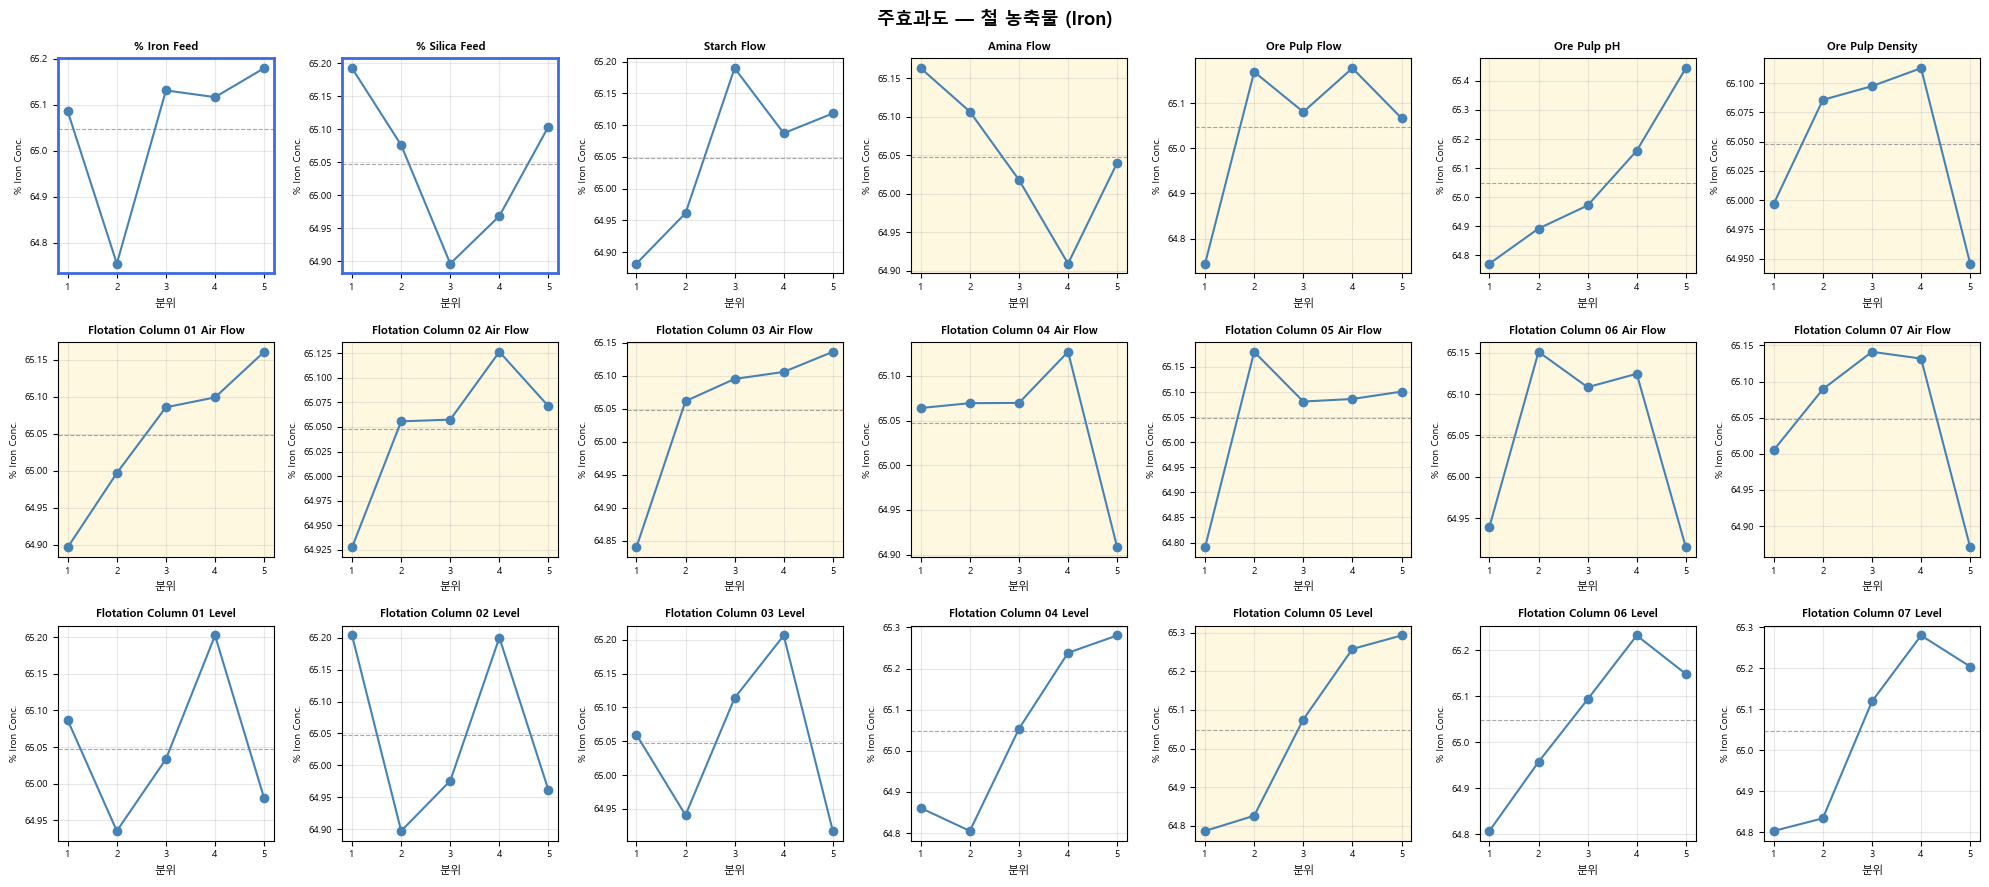

저장 완료: main_effects_%_Iro.png
  노란 배경 = p<0.05 유의 변수  |  파란 테두리 = 입력값(X01·X02)


C:\Users\USER\AppData\Local\Temp\ipykernel_3848\2780933511.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(fname, dpi=120, bbox_inches='tight')
C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


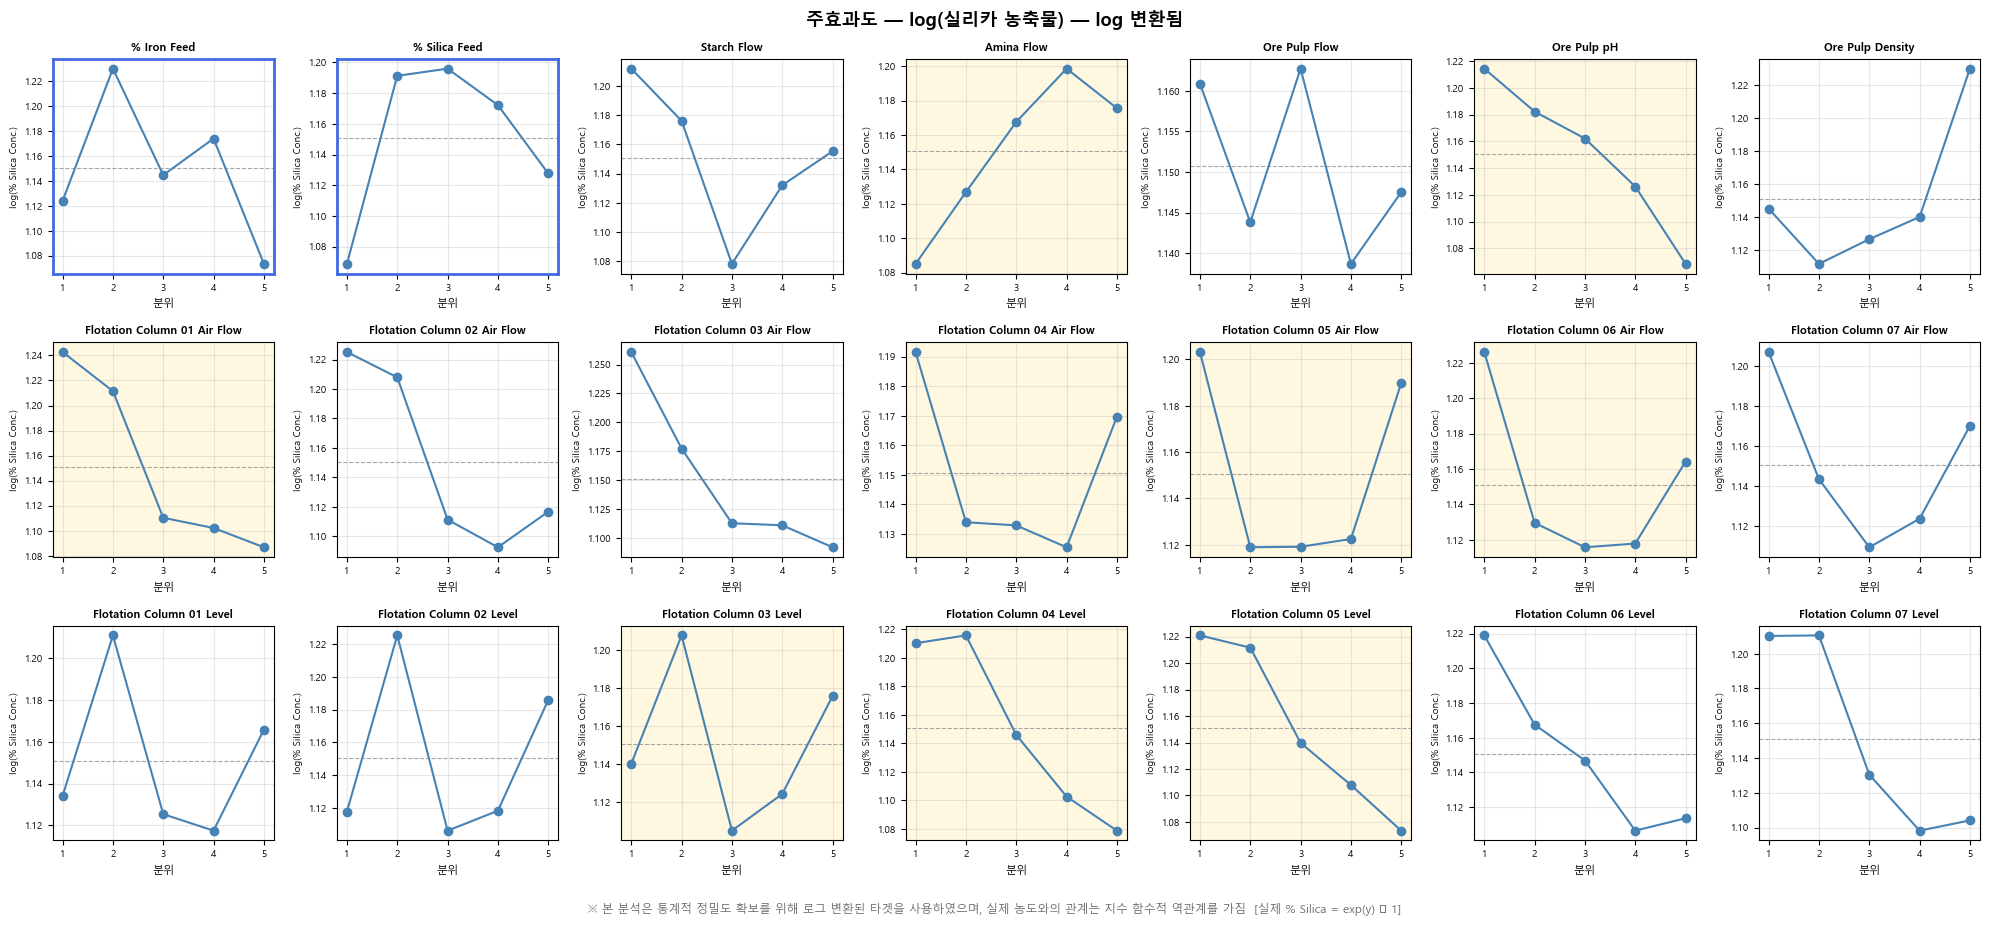

저장 완료: main_effects_%_Sil.png
  노란 배경 = p<0.05 유의 변수  |  파란 테두리 = 입력값(X01·X02)


In [33]:
# ── Step 3. 주효과도 ──────────────────────────────────────────────────────────
N_QUANTILE = 5

for target, kor in zip(TARGETS, TARGET_KOR):
    ncols = 7
    nrows = (len(X_COLS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
    y_label = 'log(% Silica Conc.)' if IS_LOG[target] else '% Iron Conc.'
    fig.suptitle(f'주효과도 — {kor}', fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for i, (col, lbl) in enumerate(zip(X_COLS, X_LABELS)):
        ax    = axes[i]
        q_bin = pd.qcut(df[col], N_QUANTILE, labels=False, duplicates='drop')
        means = df.groupby(q_bin)[target].mean()
        ax.plot(means.index + 1, means.values, 'o-', color='steelblue', lw=1.5)
        ax.axhline(df[target].mean(), color='gray', ls='--', lw=0.8, alpha=0.7)
        ax.set_title(f'{col}', fontsize=8, fontweight='bold')
        ax.set_xlabel('분위', fontsize=8)
        ax.set_ylabel(y_label, fontsize=7)
        ax.set_xticks(range(1, N_QUANTILE + 1))
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

        # 유의 변수 강조 (노란 배경)
        if lbl in sig_vars[target] and lbl not in PROTECTED:
            ax.set_facecolor('#fff8e1')
        # 입력값(X01·X02) 파란 테두리 강조
        if lbl in PROTECTED:
            for spine in ax.spines.values():
                spine.set_edgecolor('royalblue')
                spine.set_linewidth(2)

    for j in range(len(X_COLS), len(axes)):
        axes[j].set_visible(False)

    # Silica 그래프 하단 주석 (log 변환 안내)
    if IS_LOG[target]:
        fig.text(
            0.5, -0.012,
            '※ 본 분석은 통계적 정밀도 확보를 위해 로그 변환된 타겟을 사용하였으며, '
            '실제 농도와의 관계는 지수 함수적 역관계를 가짐  [실제 % Silica = exp(y) − 1]',
            ha='center', va='top', fontsize=8.5, color='dimgray', style='italic'
        )
    plt.tight_layout()
    fname = f'main_effects_{target[:5].strip().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'저장 완료: {fname}')
    print(f'  노란 배경 = p<0.05 유의 변수  |  파란 테두리 = 입력값(X01·X02)')


## Step 4. VIF — 다중공선성 확인

**VIF(Variance Inflation Factor)**: 변수 간 중복 정보가 얼마나 큰지 측정

| VIF 값 | 해석 |
|--------|------|
| 1~5    | 양호 |
| 5~10   | 주의 |
| > 10   | 제거 고려 |

> ⚠️ **X01, X02는 VIF가 10을 넘어도 제거하지 않습니다.**  
> 입력값(원광석 특성)은 공정 외부에서 들어오는 값으로, 모델에 필수적으로 포함해야 합니다.

In [34]:
# ── Step 4. VIF ───────────────────────────────────────────────────────────────
# 두 타겟의 선택 변수 합집합 기준으로 VIF 계산
all_sig = list(dict.fromkeys(
    sig_vars[TARGETS[0]] + sig_vars[TARGETS[1]]
))  # 순서 보존

if len(all_sig) < 2:
    print('유의 변수가 너무 적어 VIF 계산 생략')
else:
    sig_col_names = [X_COLS[X_LABELS.index(v)] for v in all_sig]
    X_vif = pd.DataFrame(
        scaler.fit_transform(df[sig_col_names]),
        columns=all_sig
    )
    vif_df = pd.DataFrame({
        'Var' : all_sig,
        'Name': sig_col_names,
        'VIF' : [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

    def vif_label(row):
        if row['Var'] in PROTECTED:
            return '입력값 — 제거 금지'
        elif row['VIF'] > 10:
            return '⚠ 제거 고려'
        return ''

    vif_df['비고'] = vif_df.apply(vif_label, axis=1)
    print('=== VIF 결과 (선택 변수 기준) ===')
    display(vif_df.round(2))

    # X01·X02는 제외하고 VIF 초과 변수만 제거
    high_vif = vif_df[
        (vif_df['VIF'] > 10) & (~vif_df['Var'].isin(PROTECTED))
    ]['Var'].tolist()
    print(f'\nVIF > 10이면서 제거 가능한 변수: {high_vif if high_vif else "없음"}')
    print('(X01·X02는 VIF 무관 유지)')

=== VIF 결과 (선택 변수 기준) ===


,Var,Name,VIF,비고
0,X01,% Iron Feed,19.45,입력값 — 제거 금지
1,X02,% Silica Feed,19.15,입력값 — 제거 금지
2,X10,Flotation Column 03 Air Flow,16.13,⚠ 제거 고려
3,X08,Flotation Column 01 Air Flow,13.97,⚠ 제거 고려
4,X14,Flotation Column 07 Air Flow,7.45,
5,X13,Flotation Column 06 Air Flow,6.90,
6,X09,Flotation Column 02 Air Flow,5.04,
7,X19,Flotation Column 05 Level,3.02,
8,X18,Flotation Column 04 Level,2.73,
9,X04,Amina Flow,2.25,



VIF > 10이면서 제거 가능한 변수: ['X10', 'X08']
(X01·X02는 VIF 무관 유지)


## Step 5. 단계 집계 변수 생성 (Fe_DOE와 동일 방식)

**14개 개별 Air/Level 컬럼 → 4개 집계 변수로 압축:**

| 변수 | 정의 | 의미 |
|------|------|------|
| RA (Rougher Air) | Air Col01~03 평균 | 앞단 Air 세기 |
| CA (Cleaner Air) | Air Col04~07 평균 | 뒷단 Air 세기 |
| RL (Rougher Level) | Level Col01~03 평균 | 앞단 거품층 높이 |
| CL (Cleaner Level) | Level Col04~07 평균 | 뒷단 거품층 높이 |

공정 투입 변수 7개(P01~P07) + 집계 변수 4개 = **11개** (Fe_DOE 실험 B와 동일 구성)

In [35]:
from itertools import combinations

# ── Step 5-1. 단계 집계 변수 생성 ─────────────────────────────────────────────
AIR_COLS   = [c for c in X_COLS if 'Air Flow' in c]
LEVEL_COLS = [c for c in X_COLS if 'Level' in c]

rougher_air_cols   = AIR_COLS[:3]    # Col01~03 Air
cleaner_air_cols   = AIR_COLS[3:]    # Col04~07 Air
rougher_level_cols = LEVEL_COLS[:3]  # Col01~03 Level
cleaner_level_cols = LEVEL_COLS[3:]  # Col04~07 Level

df_rsm = pd.DataFrame(index=df.index)

# 공정 투입 변수 (7개)
PROCESS_LABELS = ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07']
for col, lbl in zip(X_COLS[:7], PROCESS_LABELS):
    df_rsm[lbl] = df[col]

# 단계 집계 변수 (4개) — 비율 변수 제외
df_rsm['RA'] = df[rougher_air_cols].mean(axis=1)
df_rsm['CA'] = df[cleaner_air_cols].mean(axis=1)
df_rsm['RL'] = df[rougher_level_cols].mean(axis=1)
df_rsm['CL'] = df[cleaner_level_cols].mean(axis=1)

VAR_LABELS = list(df_rsm.columns)  # 11개
VAR_NAMES  = {
    'P01': '% Iron Feed',              'P02': '% Silica Feed',
    'P03': 'Starch Flow',              'P04': 'Amina Flow',
    'P05': 'Ore Pulp Flow',            'P06': 'Ore Pulp pH',
    'P07': 'Ore Pulp Density',
    'RA' : 'Rougher Air (Col01~03)',   'CA' : 'Cleaner Air (Col04~07)',
    'RL' : 'Rougher Level (Col01~03)', 'CL' : 'Cleaner Level (Col04~07)',
}
PROTECTED_RSM = ['P01', 'P02']

# Air→Level 인과 쌍 (같은 단계 내 교호작용 제외)
CAUSAL_PAIRS = {('RA', 'RL'), ('CA', 'CL')}

print('=== RSM 입력 변수 ===')
for lbl in VAR_LABELS:
    tag = '  ← 보호 변수' if lbl in PROTECTED_RSM else ''
    print(f'  {lbl:4s}: {VAR_NAMES[lbl]}{tag}')

print(f'\nRougher Air  : {rougher_air_cols}')
print(f'Cleaner Air  : {cleaner_air_cols}')
print(f'Rougher Level: {rougher_level_cols}')
print(f'Cleaner Level: {cleaner_level_cols}')
print(f'\n인과 쌍 (교호작용 제외): {CAUSAL_PAIRS}')
print(f'\n결측값 확인:\n{df_rsm.isnull().sum()[df_rsm.isnull().sum() > 0]}')
if df_rsm.isnull().sum().sum() == 0:
    print('  결측값 없음')

=== RSM 입력 변수 ===
  P01 : % Iron Feed  ← 보호 변수
  P02 : % Silica Feed  ← 보호 변수
  P03 : Starch Flow
  P04 : Amina Flow
  P05 : Ore Pulp Flow
  P06 : Ore Pulp pH
  P07 : Ore Pulp Density
  RA  : Rougher Air (Col01~03)
  CA  : Cleaner Air (Col04~07)
  RL  : Rougher Level (Col01~03)
  CL  : Cleaner Level (Col04~07)

Rougher Air  : ['Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow']
Cleaner Air  : ['Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow']
Rougher Level: ['Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level']
Cleaner Level: ['Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level']

인과 쌍 (교호작용 제외): {('RA', 'RL'), ('CA', 'CL')}

결측값 확인:
Series([], dtype: int64)
  결측값 없음


In [36]:
# ── Step 5-2. 최종 변수 확정 (11개) ──────────────────────────────────────────
# Fe_DOE와 동일하게 P01~P07 전체 + 집계 4개 유지 (RSM 선별 없음)
final_vars = VAR_LABELS  # ['P01','P02','P03','P04','P05','P06','P07','RA','CA','RL','CL']

print(f"=== 최종 확정 변수 ({len(final_vars)}개) ===")
for v in final_vars:
    tag = "  ← 보호 변수" if v in PROTECTED_RSM else ""
    print(f"  {v}: {VAR_NAMES[v]}{tag}")
print()
print("※ Fe_DOE 실험 B와 동일 구성 — 공정 투입 7개 + 집계 4개")

=== 최종 확정 변수 (11개) ===
  P01: % Iron Feed  ← 보호 변수
  P02: % Silica Feed  ← 보호 변수
  P03: Starch Flow
  P04: Amina Flow
  P05: Ore Pulp Flow
  P06: Ore Pulp pH
  P07: Ore Pulp Density
  RA: Rougher Air (Col01~03)
  CA: Cleaner Air (Col04~07)
  RL: Rougher Level (Col01~03)
  CL: Cleaner Level (Col04~07)

※ Fe_DOE 실험 B와 동일 구성 — 공정 투입 7개 + 집계 4개


## Step 6. XGBoost 비교 실험 — 실험 A vs 실험 B

**선행 논문 방법론 준수:**
- Time-Lag 3H (데이터에 이미 적용됨)
- Y_{t-1}, Y_{t-2} 시계열 피처 추가
- Train 70% / Test 30% (시계열 순서 유지)
- 10-fold Cross-validation

| | 실험 A | 실험 B |
|--|--------|--------|
| 방식 | 선행 논문 재현 (전체 변수) | 집계 변수 (Fe_DOE와 동일 방식) |
| 피처 | 21개 원본 변수 + lag1, lag2 (23개) | 11개 집계 변수 + lag1, lag2 (13개) |

> ※ RMSE는 log(Silica) 단위 — 선행 논문 RMSE 0.6873(원본 단위)과 직접 비교 불가

In [37]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# ── lag 피처 추가 ──────────────────────────────────────────────────────────────
TARGET = '% Silica Concentrate'

df['Silica_lag1'] = df[TARGET].shift(1)
df['Silica_lag2'] = df[TARGET].shift(2)
df_rsm['Silica_lag1'] = df['Silica_lag1']
df_rsm['Silica_lag2'] = df['Silica_lag2']

valid_idx = df.dropna(subset=['Silica_lag1', 'Silica_lag2']).index

# ── 실험 A: 전체 21개 변수 + lag (선행 논문 방식) ─────────────────────────────
feat_A = X_COLS + ['Silica_lag1', 'Silica_lag2']
X_A    = df.loc[valid_idx, feat_A]
y      = df.loc[valid_idx, TARGET]

# ── Train/Test 분할 (70/30, 시계열 순서 유지) ──────────────────────────────────
split = int(len(valid_idx) * 0.7)

X_A_train, X_A_test = X_A.iloc[:split], X_A.iloc[split:]
y_train, y_test     = y.iloc[:split],   y.iloc[split:]

# feat_B, X_B, X_B_train, X_B_test 는 VIF 셀에서 확정됨
print(f'Train: {len(y_train)}행 | Test: {len(y_test)}행')
print(f'실험 A 피처: {len(feat_A)}개')
print('실험 B 피처: VIF 셀 실행 후 확정')

Train: 2862행 | Test: 1227행
실험 A 피처: 23개
실험 B 피처: VIF 셀 실행 후 확정


In [38]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

NAME_MAP = {
    'P01': '% Iron Feed',      'P02': '% Silica Feed',
    'P03': 'Starch Flow',      'P04': 'Amina Flow',
    'P05': 'Ore Pulp Flow',    'P06': 'Ore Pulp pH',
    'P07': 'Ore Pulp Density',
    'RA' : 'Rougher Air (Col01~03)',
    'CA' : 'Cleaner Air (Col04~07)',
    'RL' : 'Rougher Level (Col01~03)',
    'CL' : 'Cleaner Level (Col04~07)',
}

def calc_vif(df_in):
    X_c  = sm.add_constant(df_in)
    cols = df_in.columns.tolist()
    vifs = [variance_inflation_factor(X_c.values, i + 1) for i in range(len(cols))]
    return pd.DataFrame({
        '변수'  : cols,
        '피처명': [NAME_MAP.get(c, c) for c in cols],
        'VIF'   : vifs,
        '보호'  : [c in {'P01', 'P02'} for c in cols],
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

# Fe_DOE와 동일: 11개 전체 유지
remaining = ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'RA', 'CA', 'RL', 'CL']
X_vif     = df_rsm.loc[valid_idx, remaining].dropna()

print('── VIF (11개 집계 변수) ──────────────────────────────────────')
vif_result = calc_vif(X_vif[remaining])
display(vif_result.round(2))
print('※ P01·P02 VIF 높음 → 보호 변수, 제거 금지')
print('※ 나머지 전체 VIF < 10 → 제거 없음')

# feat_B 확정
feat_B    = remaining + ['Silica_lag1', 'Silica_lag2']
X_B       = df_rsm.loc[valid_idx, feat_B]
X_B_train = X_B.iloc[:split]
X_B_test  = X_B.iloc[split:]
print(f'\nfeat_B 확정 ({len(feat_B)}개): {feat_B}')

── VIF (11개 집계 변수) ──────────────────────────────────────


,변수,피처명,VIF,보호
0,P01,% Iron Feed,18.97,True
1,P02,% Silica Feed,18.77,True
2,RA,Rougher Air (Col01~03),2.37,False
3,CA,Cleaner Air (Col04~07),2.34,False
4,P04,Amina Flow,2.22,False
5,P07,Ore Pulp Density,2.02,False
6,RL,Rougher Level (Col01~03),1.94,False
7,P03,Starch Flow,1.59,False
8,CL,Cleaner Level (Col04~07),1.46,False
9,P05,Ore Pulp Flow,1.27,False


※ P01·P02 VIF 높음 → 보호 변수, 제거 금지
※ 나머지 전체 VIF < 10 → 제거 없음

feat_B 확정 (13개): ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'RA', 'CA', 'RL', 'CL', 'Silica_lag1', 'Silica_lag2']


In [39]:
# ── XGBoost 실험 함수 ──────────────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators  = 300,
    learning_rate = 0.05,
    max_depth     = 6,
    random_state  = 42,
)
K = 10

def run_experiment(X_tr, X_te, label):
    fold_size = len(X_tr) // K
    cv_rmses  = []

    for k in range(K):
        val_start = k * fold_size
        val_end   = (k + 1) * fold_size if k < K - 1 else len(X_tr)
        val_idx   = list(range(val_start, val_end))
        tr_idx    = list(range(0, val_start)) + list(range(val_end, len(X_tr)))

        model = xgb.XGBRegressor(**XGB_PARAMS, verbosity=0)
        model.fit(X_tr.iloc[tr_idx], y_train.iloc[tr_idx])
        pred  = model.predict(X_tr.iloc[val_idx])
        cv_rmses.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], pred)))

    cv_rmse = np.mean(cv_rmses)
    cv_std  = np.std(cv_rmses)

    final = xgb.XGBRegressor(**XGB_PARAMS, verbosity=0)
    final.fit(X_tr, y_train)
    pred_test = final.predict(X_te)

    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    test_r2   = 1 - np.sum((y_test - pred_test)**2) / np.sum((y_test - y_test.mean())**2)

    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')
    print(f'  피처 수  : {X_tr.shape[1]}개')
    print(f'  CV RMSE  : {cv_rmse:.4f} ± {cv_std:.4f}')
    print(f'  Test RMSE: {test_rmse:.4f}')
    print(f'  Test R²  : {test_r2:.4f}')

    return final, {'cv_rmse': cv_rmse, 'cv_std': cv_std,
                   'test_rmse': test_rmse, 'test_r2': test_r2}

model_A, res_A = run_experiment(X_A_train, X_A_test, '실험 A — 전체 21개 변수 (선행 논문 방식)')
model_B, res_B = run_experiment(X_B_train, X_B_test, '실험 B — 집계 변수 13개 (Fe_DOE 동일 방식)')

# ── 최종 비교표 ────────────────────────────────────────────────────────────────
rmse_impr = (res_A['test_rmse'] - res_B['test_rmse']) / res_A['test_rmse'] * 100
r2_impr   = res_B['test_r2'] - res_A['test_r2']

print(f'\n{"="*55}')
print(f'  최종 비교')
print(f'{"="*55}')
print(f'{"":22s}  {"실험 A":>8s}  {"실험 B":>8s}  {"개선":>7s}')
print(f'  {"피처 수":20s}  {len(feat_A):>8d}  {len(feat_B):>8d}')
print(f'  {"CV RMSE":20s}  {res_A["cv_rmse"]:>8.4f}  {res_B["cv_rmse"]:>8.4f}')
print(f'  {"Test RMSE":20s}  {res_A["test_rmse"]:>8.4f}  {res_B["test_rmse"]:>8.4f}  {rmse_impr:>+6.2f}%')
print(f'  {"Test R²":20s}  {res_A["test_r2"]:>8.4f}  {res_B["test_r2"]:>8.4f}  {r2_impr:>+6.4f}')
print(f'\n선행 논문 XGBoost RMSE: 0.6873 (원본 단위 — 방법론 참고용)')
print('※ 본 실험 RMSE는 log(Silica) 단위')


  실험 A — 전체 21개 변수 (선행 논문 방식)
  피처 수  : 23개
  CV RMSE  : 0.2109 ± 0.0216
  Test RMSE: 0.2289
  Test R²  : 0.4541

  실험 B — 집계 변수 13개 (Fe_DOE 동일 방식)
  피처 수  : 13개
  CV RMSE  : 0.2132 ± 0.0213
  Test RMSE: 0.2229
  Test R²  : 0.4821

  최종 비교
                            실험 A      실험 B       개선
  피처 수                        23        13
  CV RMSE                 0.2109    0.2132
  Test RMSE               0.2289    0.2229   +2.60%
  Test R²                 0.4541    0.4821  +0.0280

선행 논문 XGBoost RMSE: 0.6873 (원본 단위 — 방법론 참고용)
※ 본 실험 RMSE는 log(Silica) 단위


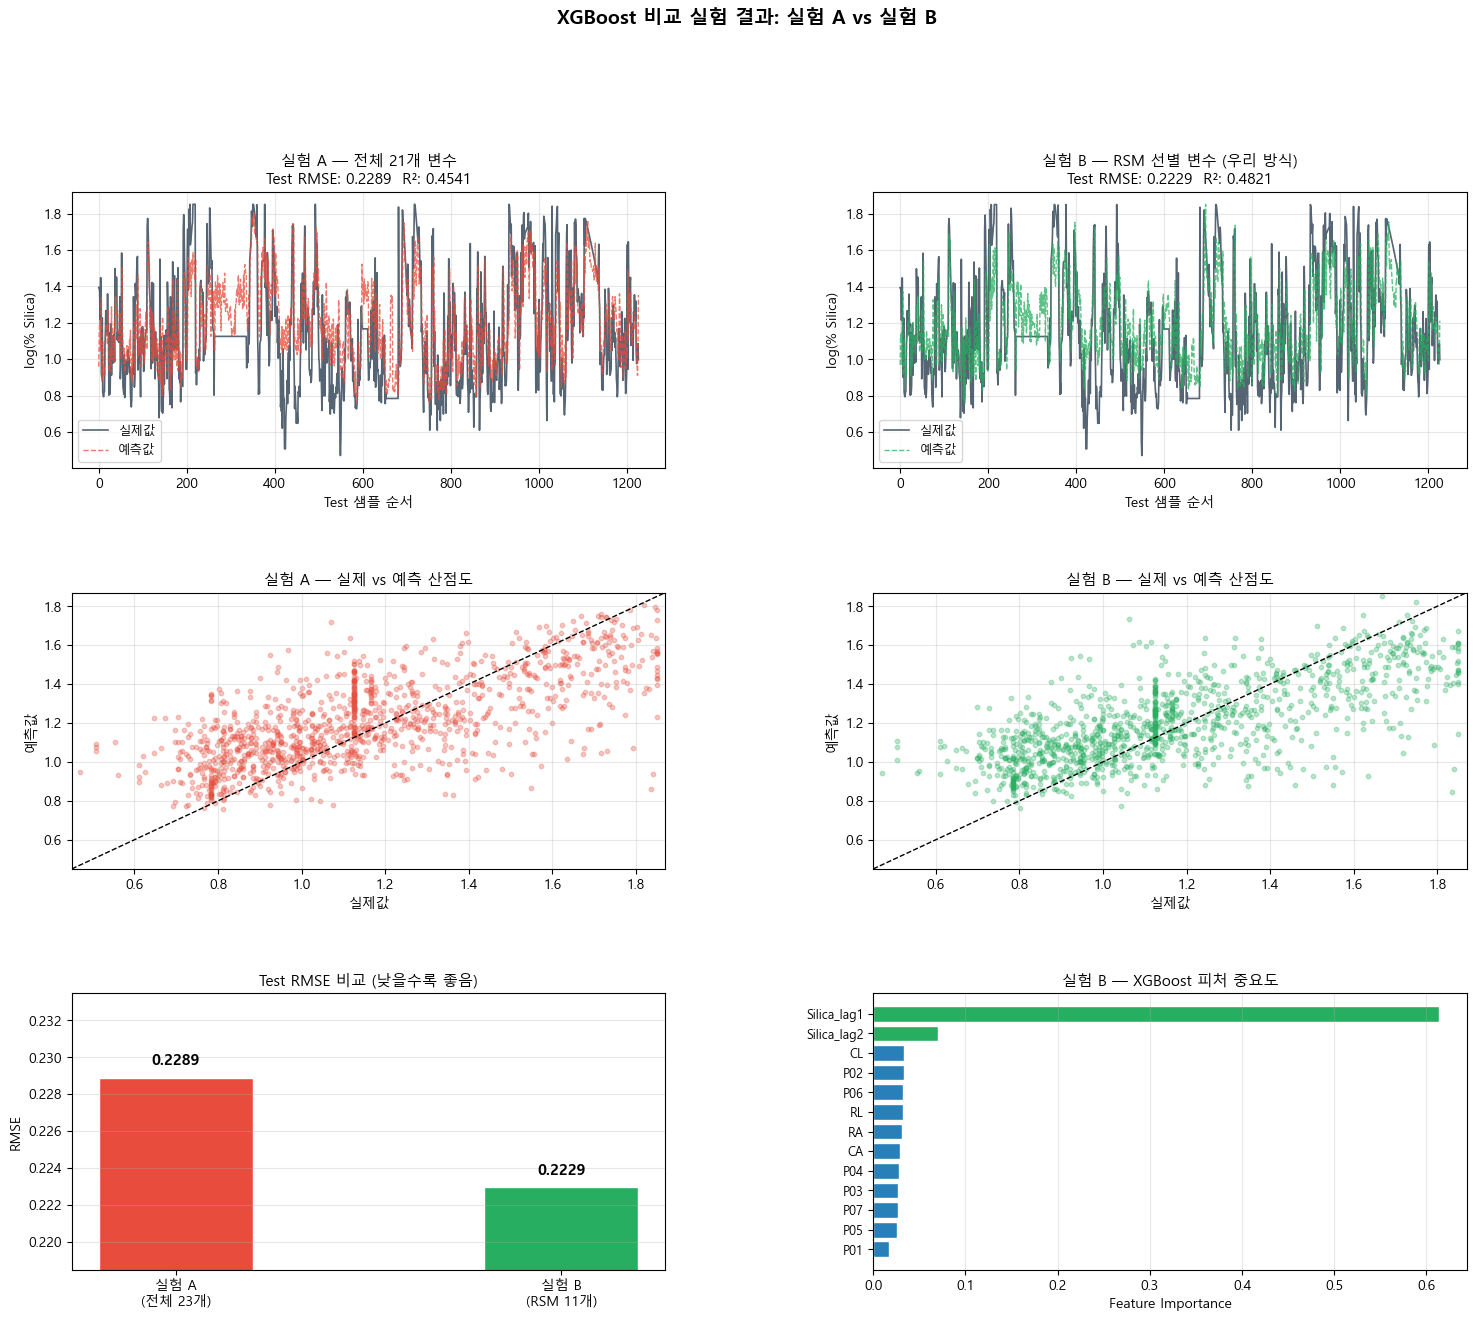

저장 완료: xgb_comparison.png


In [40]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

plt.rcParams['font.family']     = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pred_A = model_A.predict(X_A_test)
pred_B = model_B.predict(X_B_test)
y_arr  = y_test.values
x_time = np.arange(len(y_arr))

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── (1) 실제 vs 예측 — 실험 A ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x_time, y_arr,  color='#2c3e50', lw=1.2, label='실제값', alpha=0.8)
ax1.plot(x_time, pred_A, color='#e74c3c', lw=1.0, label='예측값', alpha=0.75, linestyle='--')
ax1.set_title(f'실험 A — 전체 21개 변수\nTest RMSE: {res_A["test_rmse"]:.4f}  R²: {res_A["test_r2"]:.4f}', fontsize=11)
ax1.set_xlabel('Test 샘플 순서'); ax1.set_ylabel('log(% Silica)')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# ── (2) 실제 vs 예측 — 실험 B ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(x_time, y_arr,  color='#2c3e50', lw=1.2, label='실제값', alpha=0.8)
ax2.plot(x_time, pred_B, color='#27ae60', lw=1.0, label='예측값', alpha=0.75, linestyle='--')
ax2.set_title(f'실험 B — RSM 선별 변수 (우리 방식)\nTest RMSE: {res_B["test_rmse"]:.4f}  R²: {res_B["test_r2"]:.4f}', fontsize=11)
ax2.set_xlabel('Test 샘플 순서'); ax2.set_ylabel('log(% Silica)')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# ── (3) 산점도 — 실험 A ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_arr, pred_A, alpha=0.3, s=10, color='#e74c3c')
lim = [min(y_arr.min(), pred_A.min()) - 0.02, max(y_arr.max(), pred_A.max()) + 0.02]
ax3.plot(lim, lim, 'k--', lw=1)
ax3.set_xlim(lim); ax3.set_ylim(lim)
ax3.set_title('실험 A — 실제 vs 예측 산점도', fontsize=11)
ax3.set_xlabel('실제값'); ax3.set_ylabel('예측값'); ax3.grid(alpha=0.3)

# ── (4) 산점도 — 실험 B ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(y_arr, pred_B, alpha=0.3, s=10, color='#27ae60')
ax4.plot(lim, lim, 'k--', lw=1)
ax4.set_xlim(lim); ax4.set_ylim(lim)
ax4.set_title('실험 B — 실제 vs 예측 산점도', fontsize=11)
ax4.set_xlabel('실제값'); ax4.set_ylabel('예측값'); ax4.grid(alpha=0.3)

# ── (5) RMSE / R² 비교 막대 ───────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
bars = ax5.bar(['실험 A\n(전체 23개)', '실험 B\n(RSM 11개)'],
               [res_A['test_rmse'], res_B['test_rmse']],
               color=['#e74c3c', '#27ae60'], width=0.4, edgecolor='white')
for bar, val in zip(bars, [res_A['test_rmse'], res_B['test_rmse']]):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax5.set_title('Test RMSE 비교 (낮을수록 좋음)', fontsize=11)
ax5.set_ylabel('RMSE'); ax5.grid(axis='y', alpha=0.3)
ymin = min(res_A['test_rmse'], res_B['test_rmse']) * 0.98
ymax = max(res_A['test_rmse'], res_B['test_rmse']) * 1.02
ax5.set_ylim(ymin, ymax)

ax6 = fig.add_subplot(gs[2, 1])
imp = model_B.feature_importances_
idx = np.argsort(imp)
colors = ['#27ae60' if f in ['Silica_lag1','Silica_lag2'] else '#2980b9' for f in np.array(feat_B)[idx]]
ax6.barh(np.array(feat_B)[idx], imp[idx], color=colors, edgecolor='white')
ax6.set_title('실험 B — XGBoost 피처 중요도', fontsize=11)
ax6.set_xlabel('Feature Importance'); ax6.grid(axis='x', alpha=0.3)
ax6.tick_params(axis='y', labelsize=9)

fig.suptitle('XGBoost 비교 실험 결과: 실험 A vs 실험 B', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('xgb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: xgb_comparison.png')

## Step 11. LSTM 모델 — 실험 A (23개) vs 실험 B (13개)

**목적:** XGBoost와 동일 피처셋으로 LSTM을 학습해 2×2 비교 (집계 변수 효과 + 모델 효과 분리)

- LSTM-A: 전체 23개 변수 (XGBoost-A와 동일 피처)
- LSTM-B: 집계 13개 변수 (XGBoost-B와 동일 피처)
- Lookback: 5 타임스텝 (≈ 5시간 과거 참조)
- 스케일링: StandardScaler (LSTM 필수)
- CV: EarlyStopping + val_split 10%

In [41]:
import os, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ── 재현성 고정 ──────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

LOOKBACK = 5   # 5 타임스텝 ≈ 5시간 과거 참조

print('TensorFlow:', tf.__version__)
print('LOOKBACK:', LOOKBACK)

TensorFlow: 2.21.0
LOOKBACK: 5


In [42]:
# ── 스케일링 (LSTM은 입력 범위에 민감) ─────────────────────────────────
def scale(X_tr_raw, X_te_raw):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_raw.values)
    X_te_s = scaler.transform(X_te_raw.values)
    return X_tr_s, X_te_s

# ── 시퀀스 생성: (samples, lookback, features) 3D 배열 ───────────────────
def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

print('스케일러 및 시퀀스 함수 정의 완료')

스케일러 및 시퀀스 함수 정의 완료


In [43]:
# ── LSTM 아키텍처: LSTM(64) → Dropout → LSTM(32) → Dropout → Dense(1) ──
def build_lstm(n_features, lookback):
    tf.random.set_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# ── LSTM 실험 함수 ───────────────────────────────────────────────────────
def run_lstm(X_tr_raw, X_te_raw, label, lookback=LOOKBACK):
    # 1. 스케일링
    X_tr_s, X_te_s = scale(X_tr_raw, X_te_raw)
    y_tr = y_train.values
    y_te = y_test.values

    # 2. 시퀀스 생성 (lookback만큼 앞 행 소실 — XGBoost 대비 test 크기 미세 차이)
    X_tr_seq, y_tr_seq = create_sequences(X_tr_s, y_tr, lookback)
    X_te_seq, y_te_seq = create_sequences(X_te_s, y_te, lookback)

    # 3. 학습
    model = build_lstm(X_tr_raw.shape[1], lookback)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    history = model.fit(
        X_tr_seq, y_tr_seq,
        epochs=100,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0,
    )
    stopped = len(history.history['loss'])

    # 4. 평가
    pred      = model.predict(X_te_seq, verbose=0).flatten()
    test_rmse = np.sqrt(mean_squared_error(y_te_seq, pred))
    test_r2   = 1 - np.sum((y_te_seq - pred)**2) / np.sum((y_te_seq - y_te_seq.mean())**2)

    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {label}')
    print(f'{sep}')
    print(f'  피처 수      : {X_tr_raw.shape[1]}개')
    print(f'  Lookback     : {lookback} 타임스텝')
    print(f'  학습 epoch   : {stopped} / 100 (EarlyStopping)')
    print(f'  Test RMSE    : {test_rmse:.4f}')
    print(f'  Test R²      : {test_r2:.4f}')

    return model, {'test_rmse': test_rmse, 'test_r2': test_r2}

print('LSTM 빌더 및 실험 함수 정의 완료')

LSTM 빌더 및 실험 함수 정의 완료


In [44]:
# ── LSTM 실험 실행 ──────────────────────────────────────────────────────
print('LSTM 학습 시작 (EarlyStopping patience=10, max epoch=100)...')

lstm_A, res_lstm_A = run_lstm(
    X_A_train, X_A_test, 'LSTM 실험 A — 전체 23개 변수'
)
lstm_B, res_lstm_B = run_lstm(
    X_B_train, X_B_test, 'LSTM 실험 B — RSM 선별 11개 변수'
)

LSTM 학습 시작 (EarlyStopping patience=10, max epoch=100)...

  LSTM 실험 A — 전체 23개 변수
  피처 수      : 23개
  Lookback     : 5 타임스텝
  학습 epoch   : 26 / 100 (EarlyStopping)
  Test RMSE    : 0.2915
  Test R²      : 0.1164

  LSTM 실험 B — RSM 선별 11개 변수
  피처 수      : 13개
  Lookback     : 5 타임스텝
  학습 epoch   : 17 / 100 (EarlyStopping)
  Test RMSE    : 0.2602
  Test R²      : 0.2959



  4-way 최종 비교
  모델                       Test RMSE     Test R²
  ------------------------------------------------
  XGBoost-A (23개)             0.2289      0.4541
  XGBoost-B (11개)             0.2229      0.4821
  LSTM-A    (23개)             0.2915      0.1164
  LSTM-B    (11개)             0.2602      0.2959

  [피처 선별 효과 (A → B)]
    XGBoost : RMSE +2.60%
    LSTM    : RMSE +10.73%

  [모델 효과 (XGBoost → LSTM)]
    23개 피처 : RMSE -27.35%
    11개 피처 : RMSE -16.72%

  ※ RMSE 단위: log(% Silica Concentrate)
  ※ XGBoost: 10-fold CV | LSTM: EarlyStopping + val_split 10%


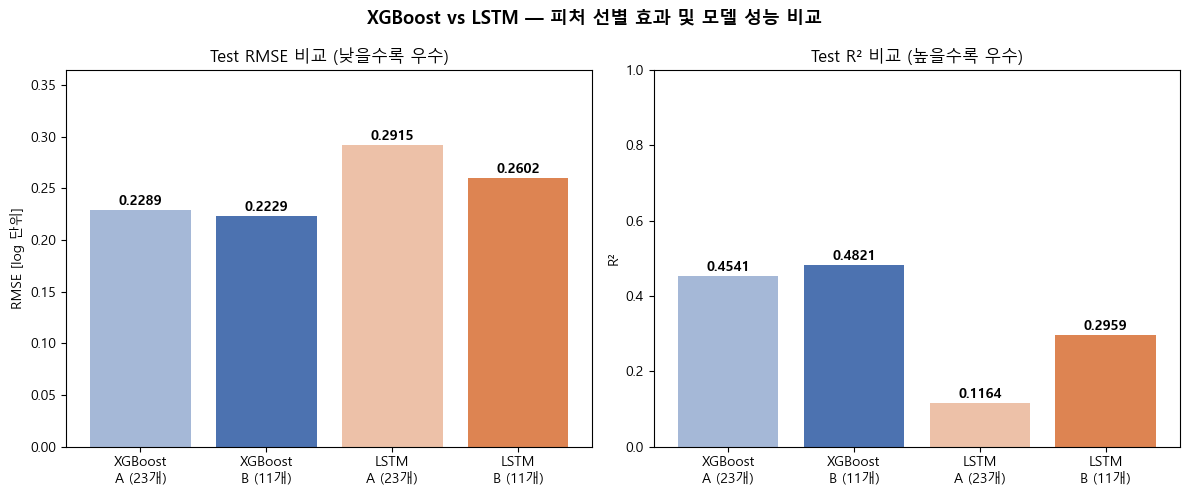

시각화 저장 완료: xgb_lstm_comparison.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Step 12. 4-way 최종 비교 (XGBoost A/B  vs  LSTM A/B)
# ══════════════════════════════════════════════════════════════════════════

results = {
    'XGBoost-A (23개)': res_A,
    'XGBoost-B (11개)': res_B,
    'LSTM-A    (23개)': res_lstm_A,
    'LSTM-B    (11개)': res_lstm_B,
}

# ── 텍스트 비교표 ────────────────────────────────────────────────────────
sep = '=' * 60
print(f'\n{sep}')
print('  4-way 최종 비교')
print(sep)
print(f'  {"모델":<22s}  {"Test RMSE":>10s}  {"Test R²":>10s}')
print(f'  {"-" * 48}')
for name, res in results.items():
    print(f'  {name:<22s}  {res["test_rmse"]:>10.4f}  {res["test_r2"]:>10.4f}')

# ── 효과 분해 ────────────────────────────────────────────────────────────
xgb_feat   = (res_A['test_rmse']      - res_B['test_rmse'])      / res_A['test_rmse']      * 100
lstm_feat  = (res_lstm_A['test_rmse'] - res_lstm_B['test_rmse']) / res_lstm_A['test_rmse'] * 100
model_full = (res_A['test_rmse']      - res_lstm_A['test_rmse']) / res_A['test_rmse']      * 100
model_sel  = (res_B['test_rmse']      - res_lstm_B['test_rmse']) / res_B['test_rmse']      * 100

print(f'\n  [피처 선별 효과 (A → B)]')
print(f'    XGBoost : RMSE {xgb_feat:+.2f}%')
print(f'    LSTM    : RMSE {lstm_feat:+.2f}%')
print(f'\n  [모델 효과 (XGBoost → LSTM)]')
print(f'    23개 피처 : RMSE {model_full:+.2f}%')
print(f'    11개 피처 : RMSE {model_sel:+.2f}%')
print('\n  ※ RMSE 단위: log(% Silica Concentrate)')
print('  ※ XGBoost: 10-fold CV | LSTM: EarlyStopping + val_split 10%')

# ── 시각화 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['XGBoost\nA (23개)', 'XGBoost\nB (11개)', 'LSTM\nA (23개)', 'LSTM\nB (11개)']
rmses  = [res_A['test_rmse'], res_B['test_rmse'], res_lstm_A['test_rmse'], res_lstm_B['test_rmse']]
r2s    = [res_A['test_r2'],   res_B['test_r2'],   res_lstm_A['test_r2'],  res_lstm_B['test_r2']]
colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']
alphas = [0.5, 1.0, 0.5, 1.0]  # A는 흐리게, B는 진하게

# RMSE 바 차트
bars = axes[0].bar(labels, rmses, color=colors)
for bar, a in zip(bars, alphas):
    bar.set_alpha(a)
for bar, val in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Test RMSE 비교 (낮을수록 우수)', fontsize=12)
axes[0].set_ylabel('RMSE [log 단위]')
axes[0].set_ylim(0, max(rmses) * 1.25)

# R² 바 차트
bars2 = axes[1].bar(labels, r2s, color=colors)
for bar, a in zip(bars2, alphas):
    bar.set_alpha(a)
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Test R² 비교 (높을수록 우수)', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.0)

plt.suptitle('XGBoost vs LSTM — 피처 선별 효과 및 모델 성능 비교',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_lstm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('시각화 저장 완료: xgb_lstm_comparison.png')

## lag 제거 실험 — 공정 변수만으로 예측 가능한가?

lag 피처의 기여도 측정:
- **with lag**: 공정 변수 + Silica_lag1, Silica_lag2
- **no lag**: 공정 변수만

→ R² 차이 = lag가 설명하는 분산 비율

In [ ]:
# ── lag 없는 피처셋 ──────────────────────────────────────────────────────────
X_A_nolag       = df.loc[valid_idx, X_COLS]
X_A_nolag_train = X_A_nolag.iloc[:split]
X_A_nolag_test  = X_A_nolag.iloc[split:]

X_B_nolag       = df_rsm.loc[valid_idx, remaining]
X_B_nolag_train = X_B_nolag.iloc[:split]
X_B_nolag_test  = X_B_nolag.iloc[split:]

print("XGBoost 학습 (lag 없음)...")
_, res_A_nl = run_experiment(X_A_nolag_train, X_A_nolag_test, f"실험 A — 전체 21개 (no lag)")
_, res_B_nl = run_experiment(X_B_nolag_train, X_B_nolag_test, f"실험 B — RSM 선별 {len(remaining)}개 (no lag)")

XGBoost 학습 (lag 없음)...

  실험 A — 전체 21개 (no lag)
  피처 수  : 21개
  CV RMSE  : 0.3282 ± 0.0438
  Test RMSE: 0.3426
  Test R²  : -0.2228

  실험 B — RSM 선별 11개 (no lag)
  피처 수  : 11개
  CV RMSE  : 0.3234 ± 0.0354
  Test RMSE: 0.3399
  Test R²  : -0.2042


  모델                                     CV RMSE  Test RMSE   Test R²
--------------------------------------------------------------------
  A — 전체 21개 + lag                        0.2109     0.2289    0.4541
  B — RSM 13개 + lag                       0.2132     0.2229    0.4821
  A — 전체 21개  (no lag)                    0.3282     0.3426   -0.2228
  B — RSM 11개 (no lag)                    0.3234     0.3399   -0.2042
=== 기여도 분석 ===
  lag 기여 R²  (A 기준): +0.6769
  lag 기여 R²  (B 기준): +0.6862
  집계 변수 기여 (with lag): +0.0280
  집계 변수 기여 (no  lag): +0.0187
  최고 성능: B — RSM 13개 + lag  →  RMSE 0.2229 / R² 0.4821


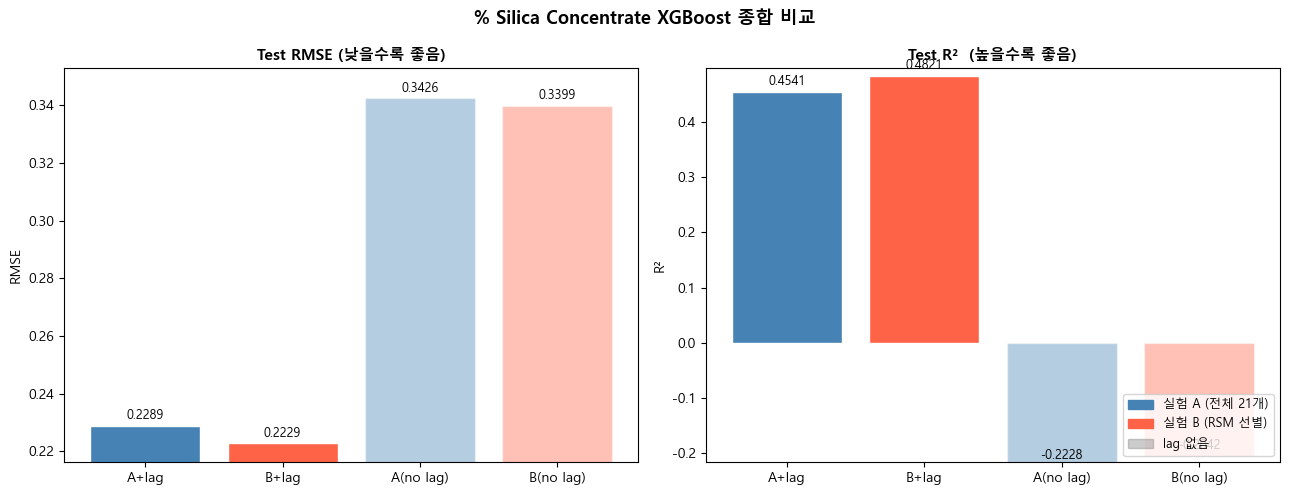

저장: xgb_SI_final_summary.png


In [ ]:
# ── 4개 실험 종합 비교표 ─────────────────────────────────────────────────────
all_results = [
    (f"A — 전체 21개 + lag",          res_A,    len(feat_A)),
    (f"B — RSM {len(feat_B)}개 + lag", res_B,    len(feat_B)),
    (f"A — 전체 21개  (no lag)",       res_A_nl, len(X_COLS)),
    (f"B — RSM {len(remaining)}개 (no lag)", res_B_nl, len(remaining)),
]

print("=" * 68)
print(f"  {'모델':<36s}  {'CV RMSE':>8}  {'Test RMSE':>9}  {'Test R²':>8}")
print("-" * 68)
for label, res, n in all_results:
    print(f"  {label:<36s}  {res['cv_rmse']:>8.4f}  {res['test_rmse']:>9.4f}  {res['test_r2']:>8.4f}")
print("=" * 68)

lag_A     = res_A['test_r2']    - res_A_nl['test_r2']
lag_B     = res_B['test_r2']    - res_B_nl['test_r2']
agg_lag   = res_B['test_r2']    - res_A['test_r2']
agg_nolag = res_B_nl['test_r2'] - res_A_nl['test_r2']

print(f"=== 기여도 분석 ===")
print(f"  lag 기여 R²  (A 기준): {lag_A:+.4f}")
print(f"  lag 기여 R²  (B 기준): {lag_B:+.4f}")
print(f"  집계 변수 기여 (with lag): {agg_lag:+.4f}")
print(f"  집계 변수 기여 (no  lag): {agg_nolag:+.4f}")

best = min(all_results, key=lambda x: x[1]['test_rmse'])
print(f"  최고 성능: {best[0]}  →  RMSE {best[1]['test_rmse']:.4f} / R² {best[1]['test_r2']:.4f}")

# 시각화
import matplotlib.patches as mpatches
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ["A+lag", "B+lag", "A(no lag)", "B(no lag)"]
rmses  = [r['test_rmse'] for _, r, _ in all_results]
r2s    = [r['test_r2']   for _, r, _ in all_results]
colors = ['steelblue','tomato','steelblue','tomato']
alphas = [1.0, 1.0, 0.4, 0.4]

for ax, vals, title, ylabel in [
    (axes[0], rmses, 'Test RMSE (낮을수록 좋음)', 'RMSE'),
    (axes[1], r2s,   'Test R²  (높을수록 좋음)',  'R²'),
]:
    bars = ax.bar(labels, vals, color=colors, edgecolor='white')
    for bar, val, alpha in zip(bars, vals, alphas):
        bar.set_alpha(alpha)
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(vals)-min(vals))*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(min(vals)*0.97, max(vals)*1.03)

lg = [mpatches.Patch(color='steelblue', label='실험 A (전체 21개)'),
      mpatches.Patch(color='tomato',     label='실험 B (RSM 선별)'),
      mpatches.Patch(color='gray', alpha=0.4, label='lag 없음')]
axes[1].legend(handles=lg, fontsize=9, loc='lower right')

plt.suptitle('% Silica Concentrate XGBoost 종합 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_SI_final_summary.png', bbox_inches='tight')
plt.show()
print("저장: xgb_SI_final_summary.png")

---
## Step 13. Random Forest Baseline

XGBoost와 **동일한 10-fold CV** 방식으로 Random Forest 학습 (집계 변수 실험 B 피처 사용)

## Step 14. One-streaming LSTM (stateful=True)

| 항목 | 기존 LSTM (Windowed) | One-streaming LSTM |
|------|---------------------|-------------------|
| 입력 | lookback=5 윈도우 묶음 | 1샘플씩 순차 입력 |
| 구현 | `stateful=False` | `stateful=True` |
| Hidden State | 예측마다 초기화 | 이전 예측에서 이어받음 |
| 실시간성 | 5시간치 필요 후 예측 | 센서 입력 즉시 예측 |
| CV 방식 | EarlyStopping | EarlyStopping (k-fold 불가) |

**추론 흐름**: `reset_states()` → 훈련 데이터 Warm-up (공정 기억 복원) → 테스트 1샘플씩 연속 예측

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Step 13. Random Forest Baseline — 10-fold CV (XGBoost와 동일 방식)
# ══════════════════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestRegressor

RF_PARAMS = dict(n_estimators=300, random_state=42, n_jobs=-1)


def run_rf_experiment(X_tr, X_te, label):
    fold_size = len(X_tr) // K
    cv_rmses  = []

    for k in range(K):
        val_start = k * fold_size
        val_end   = (k + 1) * fold_size if k < K - 1 else len(X_tr)
        val_idx   = list(range(val_start, val_end))
        tr_idx    = list(range(0, val_start)) + list(range(val_end, len(X_tr)))

        model = RandomForestRegressor(**RF_PARAMS)
        model.fit(X_tr.iloc[tr_idx], y_train.iloc[tr_idx])
        pred  = model.predict(X_tr.iloc[val_idx])
        cv_rmses.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], pred)))

    cv_rmse = np.mean(cv_rmses)
    cv_std  = np.std(cv_rmses)

    final_rf  = RandomForestRegressor(**RF_PARAMS)
    final_rf.fit(X_tr, y_train)
    pred_test = final_rf.predict(X_te)

    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    test_r2   = 1 - np.sum((y_test.values - pred_test)**2) / np.sum((y_test.values - y_test.mean())**2)

    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')
    print(f'  피처 수  : {X_tr.shape[1]}개')
    print(f'  CV RMSE  : {cv_rmse:.4f} ± {cv_std:.4f}  (10-fold)')
    print(f'  Test RMSE: {test_rmse:.4f}')
    print(f'  Test R²  : {test_r2:.4f}')

    return final_rf, {'cv_rmse': cv_rmse, 'cv_std': cv_std,
                      'test_rmse': test_rmse, 'test_r2': test_r2}


rf_B, res_rf_B = run_rf_experiment(X_B_train, X_B_test, 'Random Forest — 집계 변수 13개 (실험 B)')


  Random Forest — 집계 변수 13개 (실험 B)
  피처 수  : 13개
  CV RMSE  : 0.2072 ± 0.0226  (10-fold)
  Test RMSE: 0.2114
  Test R²  : 0.5343


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Step 14. One-streaming LSTM (stateful=True)
# ══════════════════════════════════════════════════════════════════════════
# stateful=True: hidden state가 배치(샘플) 간 유지됨
#   - 학습: 매 epoch 시작 시 reset → 순차 학습
#   - 추론: Warm-up(훈련 데이터 통과) → 테스트 1샘플씩 연속 예측 (reset 없음)

def reset_lstm_states(model):
    # TF 2.11+ 에서 model.reset_states() 미지원 → 각 LSTM 레이어 직접 리셋
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()


def build_streaming_lstm(n_features):
    tf.random.set_seed(SEED)
    # Functional API 사용 — Sequential + keras.Input 조합에서 reset_states() 미지원 문제 회피
    inp = keras.Input(batch_shape=(1, 1, n_features))
    x   = layers.LSTM(64, stateful=True, return_sequences=True)(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.LSTM(32, stateful=True)(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer='adam', loss='mse')
    return model


def run_streaming_lstm(X_tr_raw, X_te_raw, label):
    X_tr_s, X_te_s = scale(X_tr_raw, X_te_raw)
    n_features = X_tr_raw.shape[1]
    y_tr = y_train.values
    y_te = y_test.values

    # (N, 1, features) — 1 timestep씩 순차 입력
    X_tr_stream = X_tr_s.reshape(-1, 1, n_features)
    X_te_stream = X_te_s.reshape(-1, 1, n_features)

    # 마지막 10%를 validation으로 수동 분리
    val_n = int(len(X_tr_stream) * 0.1)
    X_fit, X_val = X_tr_stream[:-val_n], X_tr_stream[-val_n:]
    y_fit, y_val = y_tr[:-val_n],        y_tr[-val_n:]

    model        = build_streaming_lstm(n_features)
    best_val_mse = np.inf
    patience_cnt = 0
    PATIENCE     = 10
    best_weights = None
    stopped_ep   = 0

    for epoch in range(100):
        reset_lstm_states(model)                                # epoch 시작 시 초기화
        model.fit(X_fit, y_fit, batch_size=1, shuffle=False, verbose=0)
        # 훈련 직후 상태를 이어받아 검증 (streaming 연속성 시뮬레이션)
        val_pred = model.predict(X_val, batch_size=1, verbose=0).flatten()
        val_mse  = float(np.mean((y_val - val_pred) ** 2))

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_weights = model.get_weights()
            patience_cnt = 0
            stopped_ep   = epoch + 1
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'  EarlyStopping: epoch {epoch + 1}에서 중단')
            break

    model.set_weights(best_weights)

    # ── Streaming 추론 ────────────────────────────────────────────────────
    # 1) reset → 2) 훈련 데이터 Warm-up (공정 상태 기억 복원) → 3) 테스트 연속 예측
    reset_lstm_states(model)
    _ = model.predict(X_tr_stream, batch_size=1, verbose=0)    # warm-up
    pred = model.predict(X_te_stream, batch_size=1, verbose=0).flatten()

    test_rmse = np.sqrt(mean_squared_error(y_te, pred))
    test_r2   = 1 - np.sum((y_te - pred)**2) / np.sum((y_te - y_te.mean())**2)

    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {label}')
    print(f'{sep}')
    print(f'  피처 수        : {n_features}개')
    print(f'  학습 epoch     : {stopped_ep} / 100 (EarlyStopping)')
    print(f'  추론 방식      : Warm-up → 1샘플씩 순차 (stateful, 상태 유지)')
    print(f'  Test RMSE      : {test_rmse:.4f}')
    print(f'  Test R²        : {test_r2:.4f}')

    return model, {
        'test_rmse': test_rmse, 'test_r2': test_r2,
        'cv_rmse': None, 'stopped_ep': stopped_ep, 'pred': pred,
    }


print('One-streaming LSTM 학습 시작 (stateful=True, patience=10)...')
lstm_stream_B, res_stream_B = run_streaming_lstm(
    X_B_train, X_B_test, 'One-streaming LSTM — 집계 변수 13개 (실험 B)'
)

One-streaming LSTM 학습 시작 (stateful=True, patience=10)...
  EarlyStopping: epoch 12에서 중단

  One-streaming LSTM — 집계 변수 13개 (실험 B)
  피처 수        : 13개
  학습 epoch     : 2 / 100 (EarlyStopping)
  추론 방식      : Warm-up → 1샘플씩 순차 (stateful, 상태 유지)
  Test RMSE      : 0.2261
  Test R²        : 0.4674


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Step 14-2. MLP (Multi-Layer Perceptron) — EarlyStopping
# ══════════════════════════════════════════════════════════════════════════
# 시계열 구조 없는 순수 피드포워드 신경망
# XGBoost와 동일 피처 사용, 스케일링 필요

def build_mlp(n_features):
    tf.random.set_seed(SEED)
    inp = keras.Input(shape=(n_features,))
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(64,  activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer='adam', loss='mse')
    return model


def run_mlp(X_tr_raw, X_te_raw, label):
    X_tr_s, X_te_s = scale(X_tr_raw, X_te_raw)
    y_tr = y_train.values
    y_te = y_test.values

    model      = build_mlp(X_tr_raw.shape[1])
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    history = model.fit(
        X_tr_s, y_tr,
        epochs=200,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0,
    )
    stopped = len(history.history['loss'])

    pred      = model.predict(X_te_s, verbose=0).flatten()
    test_rmse = np.sqrt(mean_squared_error(y_te, pred))
    test_r2   = 1 - np.sum((y_te - pred)**2) / np.sum((y_te - y_te.mean())**2)

    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')
    print(f'  피처 수        : {X_tr_raw.shape[1]}개')
    print(f'  학습 epoch     : {stopped} / 200 (EarlyStopping)')
    print(f'  Test RMSE      : {test_rmse:.4f}')
    print(f'  Test R²        : {test_r2:.4f}')

    return model, {'test_rmse': test_rmse, 'test_r2': test_r2,
                   'cv_rmse': None, 'pred': pred}


print('MLP 학습 시작...')
mlp_B, res_mlp_B = run_mlp(X_B_train, X_B_test, 'MLP — 집계 변수 13개 (실험 B)')

MLP 학습 시작...

  MLP — 집계 변수 13개 (실험 B)
  피처 수        : 13개
  학습 epoch     : 31 / 200 (EarlyStopping)
  Test RMSE      : 0.2193
  Test R²        : 0.4988


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Step 14-3. LightGBM — 10-fold CV (XGBoost와 동일 방식)
# ══════════════════════════════════════════════════════════════════════════
import lightgbm as lgb

LGBM_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)


def run_lgbm_experiment(X_tr, X_te, label):
    fold_size = len(X_tr) // K
    cv_rmses  = []

    for k in range(K):
        val_start = k * fold_size
        val_end   = (k + 1) * fold_size if k < K - 1 else len(X_tr)
        val_idx   = list(range(val_start, val_end))
        tr_idx    = list(range(0, val_start)) + list(range(val_end, len(X_tr)))

        model = lgb.LGBMRegressor(**LGBM_PARAMS)
        model.fit(X_tr.iloc[tr_idx], y_train.iloc[tr_idx])
        pred  = model.predict(X_tr.iloc[val_idx])
        cv_rmses.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], pred)))

    cv_rmse = np.mean(cv_rmses)
    cv_std  = np.std(cv_rmses)

    final_lgbm = lgb.LGBMRegressor(**LGBM_PARAMS)
    final_lgbm.fit(X_tr, y_train)
    pred_test = final_lgbm.predict(X_te)

    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    test_r2   = 1 - np.sum((y_test.values - pred_test)**2) / np.sum((y_test.values - y_test.mean())**2)

    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')
    print(f'  피처 수  : {X_tr.shape[1]}개')
    print(f'  CV RMSE  : {cv_rmse:.4f} ± {cv_std:.4f}  (10-fold)')
    print(f'  Test RMSE: {test_rmse:.4f}')
    print(f'  Test R²  : {test_r2:.4f}')

    return final_lgbm, {'cv_rmse': cv_rmse, 'cv_std': cv_std,
                        'test_rmse': test_rmse, 'test_r2': test_r2,
                        'pred': pred_test}


print('LightGBM 학습 시작...')
lgbm_B, res_lgbm_B = run_lgbm_experiment(X_B_train, X_B_test, 'LightGBM — 집계 변수 13개 (실험 B)')


LightGBM 학습 시작...

  LightGBM — 집계 변수 13개 (실험 B)
  피처 수  : 13개
  CV RMSE  : 0.2061 ± 0.0202  (10-fold)
  Test RMSE: 0.2051
  Test R²  : 0.5616


## Step 15. 최종 모델 비교 (집계 변수 13개 — 실험 B)

| 모델 | 유형 | CV 방식 |
|------|------|---------|
| Random Forest | 트리 앙상블 (Baseline) | 10-fold CV |
| XGBoost | 트리 앙상블 (Gradient Boosting) | 10-fold CV |
| LightGBM | 트리 앙상블 (Leaf-wise Boosting) | 10-fold CV |
| MLP | 피드포워드 신경망 | EarlyStopping |
| LSTM (Windowed) | 시계열 딥러닝 (lookback=5) | EarlyStopping |
| One-streaming LSTM | 시계열 딥러닝 (stateful, 실시간) | EarlyStopping |

> **주의**: LSTM 계열은 EarlyStopping 방식 — k-fold CV 미적용



  최종 6-way 모델 비교 (집계 변수 13개, 실험 B)
  모델                             CV RMSE   Test RMSE   Test R²           검증 방식
  ------------------------------------------------------------------------
  Random Forest                   0.2072      0.2114    0.5343      10-fold CV
  XGBoost                         0.2132      0.2229    0.4821      10-fold CV
  LightGBM                        0.2061      0.2051    0.5616      10-fold CV
  MLP                                N/A      0.2193    0.4988   EarlyStopping
  LSTM (Windowed)                    N/A      0.2602    0.2959   EarlyStopping
  One-streaming LSTM                 N/A      0.2261    0.4674   EarlyStopping
  ※ RMSE 단위: log(% Silica Concentrate)
  ※ LSTM 계열은 k-fold CV 미적용 — EarlyStopping + val_split 10% 사용


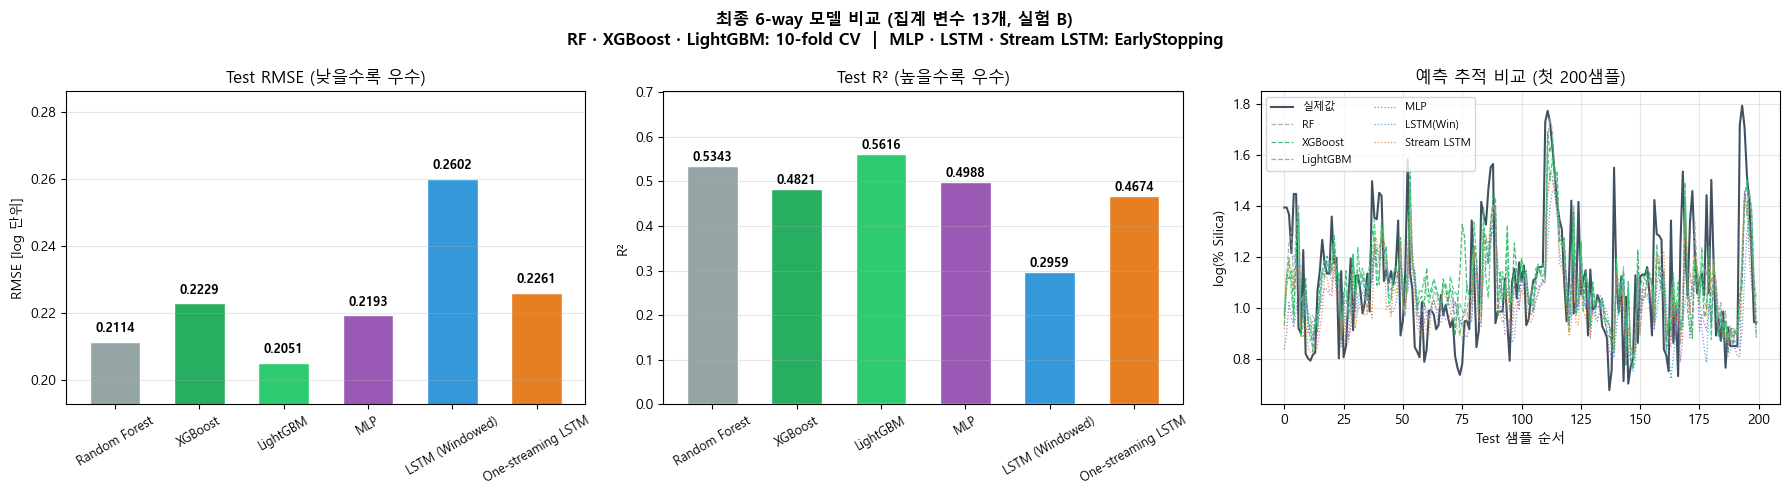

저장 완료: model_comparison.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Step 15. 최종 6-way 모델 비교 (집계 변수 13개, 실험 B)
# ══════════════════════════════════════════════════════════════════════════

all_models = {
    'Random Forest':        (res_rf_B,     '10-fold CV'),
    'XGBoost':              (res_B,        '10-fold CV'),
    'LightGBM':             (res_lgbm_B,   '10-fold CV'),
    'MLP':                  (res_mlp_B,    'EarlyStopping'),
    'LSTM (Windowed)':      (res_lstm_B,   'EarlyStopping'),
    'One-streaming LSTM':   (res_stream_B, 'EarlyStopping'),
}

sep = '=' * 76
print(f'\n{sep}')
print('  최종 6-way 모델 비교 (집계 변수 13개, 실험 B)')
print(sep)
print(f'  {"모델":<24s}  {"CV RMSE":>12s}  {"Test RMSE":>10s}  {"Test R²":>8s}  {"검증 방식":>14s}')
print(f'  {"-"*72}')
for name, (res, cv_m) in all_models.items():
    cv_str = f'{res["cv_rmse"]:.4f}' if res.get('cv_rmse') is not None else '         N/A'
    print(f'  {name:<24s}  {cv_str:>12s}  {res["test_rmse"]:>10.4f}  {res["test_r2"]:>8.4f}  {cv_m:>14s}')
print(sep)
print('  ※ RMSE 단위: log(% Silica Concentrate)')
print('  ※ LSTM 계열은 k-fold CV 미적용 — EarlyStopping + val_split 10% 사용')

# ── 시각화 ───────────────────────────────────────────────────────────────────
model_labels = list(all_models.keys())
rmses  = [v[0]['test_rmse'] for v in all_models.values()]
r2s    = [v[0]['test_r2']   for v in all_models.values()]
colors = ['#95a5a6', '#27ae60', '#2ecc71', '#9b59b6', '#3498db', '#e67e22']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) RMSE 바 차트
bars = axes[0].bar(model_labels, rmses, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Test RMSE (낮을수록 우수)', fontsize=12)
axes[0].set_ylabel('RMSE [log 단위]')
axes[0].set_ylim(min(rmses) * 0.94, max(rmses) * 1.10)
axes[0].tick_params(axis='x', labelrotation=30, labelsize=9)
axes[0].grid(axis='y', alpha=0.3)

# (2) R² 바 차트
bars2 = axes[1].bar(model_labels, r2s, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Test R² (높을수록 우수)', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].set_ylim(min(0, min(r2s) - 0.05), max(r2s) * 1.25)
axes[1].tick_params(axis='x', labelrotation=30, labelsize=9)
axes[1].grid(axis='y', alpha=0.3)

# (3) 예측 추적 비교 (처음 200샘플)
n_show = 200
y_arr = y_test.values

pred_rf_arr     = rf_B.predict(X_B_test)
pred_xgb_arr    = model_B.predict(X_B_test)
pred_lgbm_arr   = lgbm_B.predict(X_B_test)
pred_mlp_arr    = res_mlp_B['pred']
pred_stream_arr = res_stream_B['pred']

# LSTM windowed — pred가 저장돼 있으면 사용, 없으면 재예측
if 'pred' in res_lstm_B:
    pred_lstm_arr = res_lstm_B['pred']
else:
    X_B_te_s = scale(X_B_train, X_B_test)[1]
    X_B_te_win = np.array([X_B_te_s[i:i+LOOKBACK] for i in range(len(X_B_te_s)-LOOKBACK+1)])
    pred_lstm_arr_full = lstm_B.predict(X_B_te_win, verbose=0).flatten()
    pad = np.full(LOOKBACK - 1, np.nan)
    pred_lstm_arr = np.concatenate([pad, pred_lstm_arr_full])

plot_pairs = [
    (pred_rf_arr,     '#95a5a6', 'RF',           '--'),
    (pred_xgb_arr,    '#27ae60', 'XGBoost',      '--'),
    (pred_lgbm_arr,   '#2ecc71', 'LightGBM',     '--'),
    (pred_mlp_arr,    '#9b59b6', 'MLP',           ':'),
    (pred_lstm_arr,   '#3498db', 'LSTM(Win)',      ':'),
    (pred_stream_arr, '#e67e22', 'Stream LSTM',   ':'),
]

axes[2].plot(y_arr[:n_show], color='#2c3e50', lw=1.5, label='실제값', alpha=0.9)
for pred_arr, col, lbl, ls in plot_pairs:
    axes[2].plot(np.array(pred_arr[:n_show], dtype=float),
                 color=col, lw=0.9, label=lbl, linestyle=ls, alpha=0.85)
axes[2].set_title(f'예측 추적 비교 (첫 {n_show}샘플)', fontsize=12)
axes[2].set_xlabel('Test 샘플 순서')
axes[2].set_ylabel('log(% Silica)')
axes[2].legend(fontsize=8, ncol=2)
axes[2].grid(alpha=0.3)

plt.suptitle(
    '최종 6-way 모델 비교 (집계 변수 13개, 실험 B)\n'
    'RF · XGBoost · LightGBM: 10-fold CV  |  MLP · LSTM · Stream LSTM: EarlyStopping',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: model_comparison.png')


## Step 16. Optuna 하이퍼파라미터 튜닝 — LightGBM / XGBoost / Random Forest

**방법**: TPE (Tree-structured Parzen Estimator) 베이지안 최적화
- 이전 시도 결과를 기억해 좋은 파라미터 구간을 집중 탐색
- 평가 기준: 10-fold sequential CV RMSE (시계열 순서 유지)
- 모델당 **100 trials**

| 모델 | 주요 튜닝 파라미터 |
|------|-------------------|
| LightGBM | learning_rate, num_leaves, max_depth, min_child_samples, subsample, colsample_bytree |
| XGBoost | learning_rate, max_depth, n_estimators, subsample, colsample_bytree, min_child_weight, gamma |
| Random Forest | n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features |


In [ ]:
!pip install optuna -q



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Step 16. Optuna 튜닝 — LightGBM / XGBoost / RandomForest
# ══════════════════════════════════════════════════════════════════════════
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 100


def cv_rmse(model, X_tr, y_tr):
    fold_size = len(X_tr) // K
    rmses = []
    for k in range(K):
        val_start = k * fold_size
        val_end   = (k + 1) * fold_size if k < K - 1 else len(X_tr)
        val_idx = list(range(val_start, val_end))
        tr_idx  = list(range(0, val_start)) + list(range(val_end, len(X_tr)))
        model.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        pred = model.predict(X_tr.iloc[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y_tr.iloc[val_idx], pred)))
    return float(np.mean(rmses))


# ── LightGBM objective ────────────────────────────────────────────────────
def lgbm_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 300),
        max_depth         = trial.suggest_int('max_depth', 3, 15),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        random_state=42, n_jobs=-1, verbose=-1,
    )
    return cv_rmse(lgb.LGBMRegressor(**params), X_B_train, y_train)


# ── XGBoost objective ─────────────────────────────────────────────────────
def xgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma             = trial.suggest_float('gamma', 0.0, 5.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        random_state=42, verbosity=0,
    )
    return cv_rmse(xgb.XGBRegressor(**params), X_B_train, y_train)


# ── Random Forest objective ───────────────────────────────────────────────
def rf_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 1000),
        max_depth        = trial.suggest_int('max_depth', 3, 30),
        min_samples_split= trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features     = trial.suggest_float('max_features', 0.3, 1.0),
        random_state=42, n_jobs=-1,
    )
    return cv_rmse(RandomForestRegressor(**params), X_B_train, y_train)


# ── 튜닝 실행 ─────────────────────────────────────────────────────────────
print('=' * 55)
print('  Optuna 튜닝 시작 (모델당 100 trials)')
print('=' * 55)

study_lgbm = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
print('\n[1/3] LightGBM 튜닝 중...')
study_lgbm.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'  Best CV RMSE: {study_lgbm.best_value:.4f}')
print(f'  Best params : {study_lgbm.best_params}')

study_xgb = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
print('\n[2/3] XGBoost 튜닝 중...')
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'  Best CV RMSE: {study_xgb.best_value:.4f}')
print(f'  Best params : {study_xgb.best_params}')

study_rf = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
print('\n[3/3] Random Forest 튜닝 중...')
study_rf.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'  Best CV RMSE: {study_rf.best_value:.4f}')
print(f'  Best params : {study_rf.best_params}')

print('\n튜닝 완료!')


  Optuna 튜닝 시작 (모델당 100 trials)

[1/3] LightGBM 튜닝 중...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best CV RMSE: 0.1980
  Best params : {'n_estimators': 212, 'learning_rate': 0.024500531434689807, 'num_leaves': 71, 'max_depth': 3, 'min_child_samples': 75, 'subsample': 0.6323139110299589, 'colsample_bytree': 0.8249253374391537, 'reg_alpha': 0.00020537045370908944, 'reg_lambda': 0.0003023478689713925}

[2/3] XGBoost 튜닝 중...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best CV RMSE: 0.1976
  Best params : {'n_estimators': 987, 'learning_rate': 0.031228516359039043, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.6793521428151174, 'colsample_bytree': 0.6322281338837362, 'gamma': 0.24051325839306834, 'reg_alpha': 4.0649709472630416e-07, 'reg_lambda': 0.00037205376574109365}

[3/3] Random Forest 튜닝 중...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best CV RMSE: 0.1981
  Best params : {'n_estimators': 777, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 0.7436642915610611}

튜닝 완료!



  Optuna 튜닝 전후 비교
  모델                          Best CV RMSE   Test RMSE   Test R²
  ------------------------------------------------------------------
  LightGBM  (default)               0.1980      0.2051    0.5616
  LightGBM  (tuned)                      -      0.1906    0.6215
  XGBoost   (default)               0.1976      0.2229    0.4821
  XGBoost   (tuned)                      -      0.1908    0.6206
  RF        (default)               0.1981      0.2114    0.5343
  RF        (tuned)                      -      0.1902    0.6229
  ※ Best CV RMSE: Optuna가 최적화한 10-fold CV RMSE

  ★ 최종 우승 모델: RF (Tuned)
     Test RMSE = 0.1902 | Test R² = 0.6229


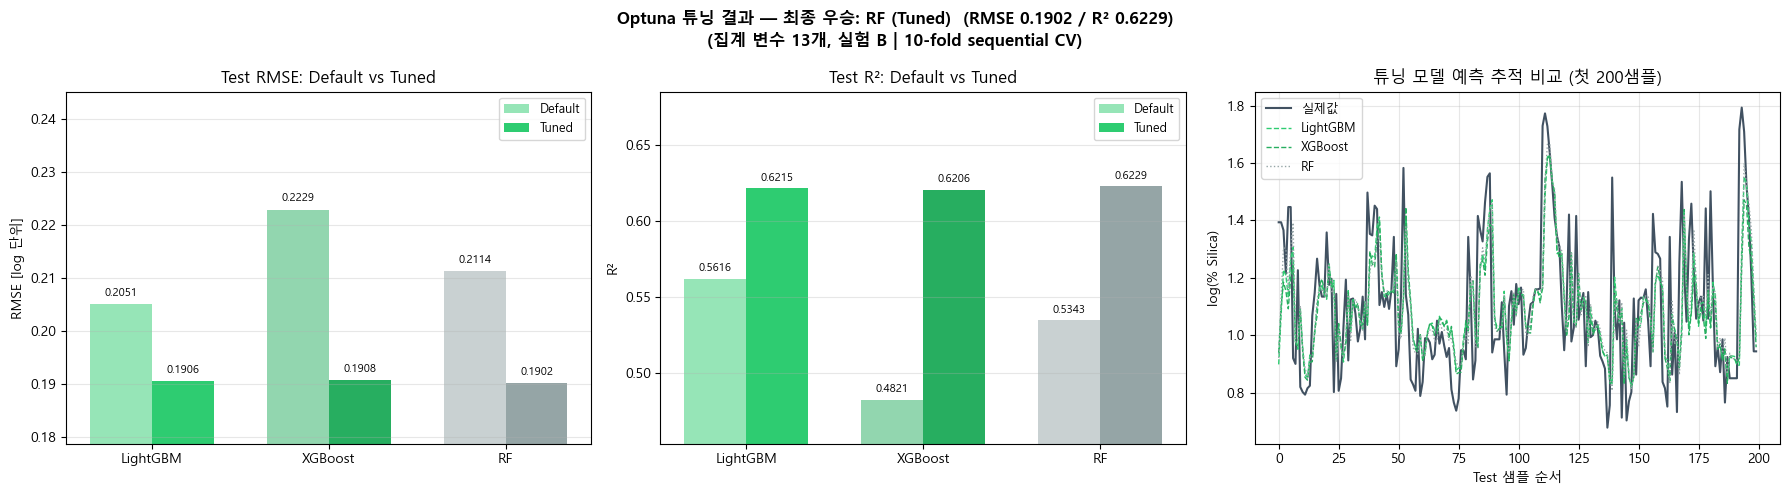

저장 완료: optuna_tuning_result.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# Step 16-2. 튜닝 모델 최종 평가 및 비교
# ══════════════════════════════════════════════════════════════════════════

def eval_model(model, X_tr, X_te):
    model.fit(X_tr, y_train)
    pred      = model.predict(X_te)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    test_r2   = 1 - np.sum((y_test.values - pred)**2) / np.sum((y_test.values - y_test.mean())**2)
    return pred, {'test_rmse': test_rmse, 'test_r2': test_r2, 'pred': pred}


# 최적 파라미터로 재학습
tuned_lgbm = lgb.LGBMRegressor(**study_lgbm.best_params, random_state=42, n_jobs=-1, verbose=-1)
tuned_xgb  = xgb.XGBRegressor(**study_xgb.best_params,  random_state=42, verbosity=0)
tuned_rf   = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)

_, res_tuned_lgbm = eval_model(tuned_lgbm, X_B_train, X_B_test)
_, res_tuned_xgb  = eval_model(tuned_xgb,  X_B_train, X_B_test)
_, res_tuned_rf   = eval_model(tuned_rf,   X_B_train, X_B_test)

# ── 텍스트 비교표 ─────────────────────────────────────────────────────────
compare = [
    ('LightGBM  (default)', res_lgbm_B,    study_lgbm.best_value),
    ('LightGBM  (tuned)',   res_tuned_lgbm, None),
    ('XGBoost   (default)', res_B,          study_xgb.best_value),
    ('XGBoost   (tuned)',   res_tuned_xgb,  None),
    ('RF        (default)', res_rf_B,        study_rf.best_value),
    ('RF        (tuned)',   res_tuned_rf,    None),
]

SEP = '=' * 70
print(f'\n{SEP}')
print('  Optuna 튜닝 전후 비교')
print(SEP)
print(f'  {"모델":<26s}  {"Best CV RMSE":>12s}  {"Test RMSE":>10s}  {"Test R²":>8s}')
print(f'  {"-"*66}')
for name, res, cv_val in compare:
    cv_str = f'{cv_val:.4f}' if cv_val is not None else '          -'
    print(f'  {name:<26s}  {cv_str:>12s}  {res["test_rmse"]:>10.4f}  {res["test_r2"]:>8.4f}')
print(SEP)
print('  ※ Best CV RMSE: Optuna가 최적화한 10-fold CV RMSE')

# 최종 우승자
tuned_results = [
    ('LightGBM (Tuned)', res_tuned_lgbm),
    ('XGBoost (Tuned)',  res_tuned_xgb),
    ('RF (Tuned)',       res_tuned_rf),
]
winner_name, winner_res = min(tuned_results, key=lambda x: x[1]['test_rmse'])
print(f'\n  ★ 최종 우승 모델: {winner_name}')
print(f'     Test RMSE = {winner_res["test_rmse"]:.4f} | Test R² = {winner_res["test_r2"]:.4f}')

# ── 시각화 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(3)
w = 0.35

rmse_def   = [res_lgbm_B['test_rmse'],    res_B['test_rmse'],       res_rf_B['test_rmse']]
rmse_tuned = [res_tuned_lgbm['test_rmse'], res_tuned_xgb['test_rmse'], res_tuned_rf['test_rmse']]
r2_def     = [res_lgbm_B['test_r2'],      res_B['test_r2'],         res_rf_B['test_r2']]
r2_tuned   = [res_tuned_lgbm['test_r2'],   res_tuned_xgb['test_r2'],   res_tuned_rf['test_r2']]
colors     = ['#2ecc71', '#27ae60', '#95a5a6']

# (1) RMSE 비교 (default vs tuned)
b1 = axes[0].bar(x - w/2, rmse_def,   w, label='Default', color=colors, alpha=0.5)
b2 = axes[0].bar(x + w/2, rmse_tuned, w, label='Tuned',   color=colors, alpha=1.0)
for bar, val in zip(list(b1)+list(b2), rmse_def+rmse_tuned):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['LightGBM', 'XGBoost', 'RF'], fontsize=10)
axes[0].set_title('Test RMSE: Default vs Tuned', fontsize=12)
axes[0].set_ylabel('RMSE [log 단위]')
axes[0].set_ylim(min(rmse_def+rmse_tuned)*0.94, max(rmse_def+rmse_tuned)*1.10)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# (2) R² 비교 (default vs tuned)
b3 = axes[1].bar(x - w/2, r2_def,   w, label='Default', color=colors, alpha=0.5)
b4 = axes[1].bar(x + w/2, r2_tuned, w, label='Tuned',   color=colors, alpha=1.0)
for bar, val in zip(list(b3)+list(b4), r2_def+r2_tuned):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['LightGBM', 'XGBoost', 'RF'], fontsize=10)
axes[1].set_title('Test R²: Default vs Tuned', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].set_ylim(min(r2_def+r2_tuned)*0.94, max(r2_def+r2_tuned)*1.10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# (3) 최종 3 tuned 모델 예측 추적 비교
n_show = 200
y_arr = y_test.values
axes[2].plot(y_arr[:n_show], color='#2c3e50', lw=1.5, label='실제값', alpha=0.9)
axes[2].plot(res_tuned_lgbm['pred'][:n_show], color='#2ecc71', lw=1.0, label='LightGBM', linestyle='--')
axes[2].plot(res_tuned_xgb['pred'][:n_show],  color='#27ae60', lw=1.0, label='XGBoost',  linestyle='--')
axes[2].plot(res_tuned_rf['pred'][:n_show],   color='#95a5a6', lw=1.0, label='RF',        linestyle=':')
axes[2].set_title(f'튜닝 모델 예측 추적 비교 (첫 {n_show}샘플)', fontsize=12)
axes[2].set_xlabel('Test 샘플 순서')
axes[2].set_ylabel('log(% Silica)')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle(
    f'Optuna 튜닝 결과 — 최종 우승: {winner_name}  (RMSE {winner_res["test_rmse"]:.4f} / R² {winner_res["test_r2"]:.4f})\n'
    '(집계 변수 13개, 실험 B | 10-fold sequential CV)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('optuna_tuning_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: optuna_tuning_result.png')


In [30]:
# ── 튜닝 모델 저장 (Optuna 재실행 방지) ─────────────────────────────────────
# 처음 한 번만 실행. 이후엔 아래 로드 셀만 실행하면 됨.
import joblib
joblib.dump(tuned_lgbm, 'si_tuned_lgbm.pkl')
joblib.dump(tuned_xgb,  'si_tuned_xgb.pkl')
joblib.dump(tuned_rf,   'si_tuned_rf.pkl')
print('모델 저장 완료: si_tuned_lgbm.pkl / si_tuned_xgb.pkl / si_tuned_rf.pkl')

# ── 다음 번 실행 시 아래 코드로 불러오기 (Optuna 셀 건너뛰고 이것만 실행) ──
# import joblib
# tuned_lgbm = joblib.load('si_tuned_lgbm.pkl')
# tuned_xgb  = joblib.load('si_tuned_xgb.pkl')
# tuned_rf   = joblib.load('si_tuned_rf.pkl')
# print('모델 로드 완료')


모델 저장 완료: si_tuned_lgbm.pkl / si_tuned_xgb.pkl / si_tuned_rf.pkl


--------------------------------------------------------------
   split      LightGBM       XGBoost            RF
--------------------------------------------------------------
  60%      0.1974        ★0.1972          0.1980
  65%    ★0.1929          0.1932          0.1930
  70%      0.1906          0.1908        ★0.1902
  75%      0.1865          0.1859        ★0.1854
  80%      0.1900          0.1900        ★0.1896
--------------------------------------------------------------
      평균        0.1915        0.1914        0.1913
    표준편차        0.0036        0.0037        0.0042
--------------------------------------------------------------

  ★ 5회 평균 기준 최종 우승: RF (Tuned)
     평균 RMSE = 0.1913 ± 0.0042


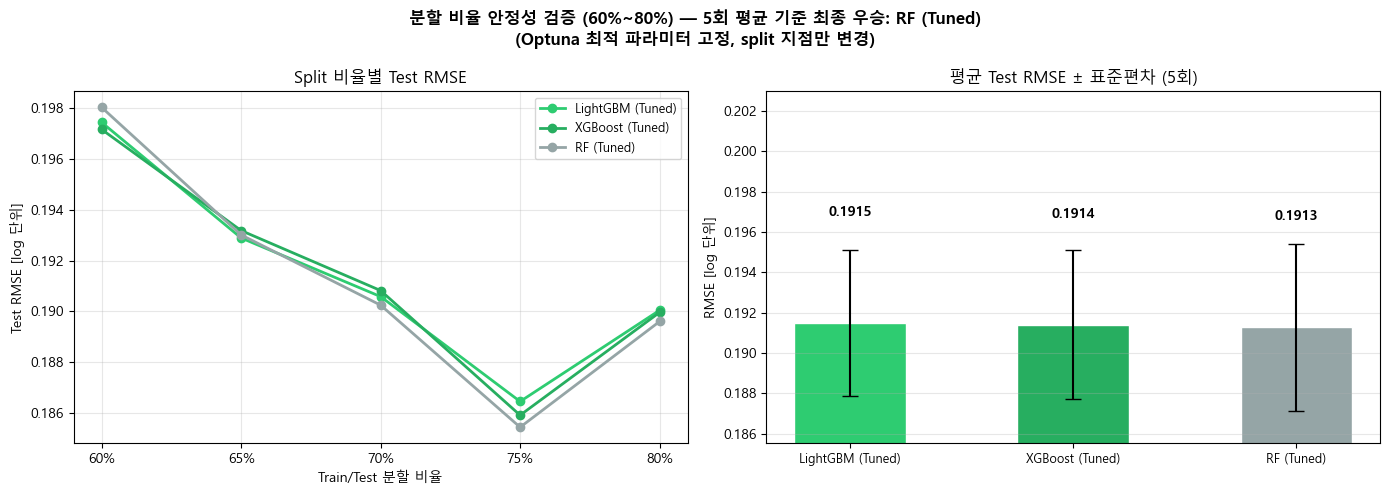

저장 완료: stability_check.png


In [28]:
# ══════════════════════════════════════════════════════════════════════════
# Step 16-3. 분할 비율 변경 안정성 검증 — 진짜 순위 확인
# ══════════════════════════════════════════════════════════════════════════
# 시계열 데이터라 shuffle 불가 → split 지점을 이동해 5회 반복
from sklearn.base import clone
import pandas as pd

X_full = pd.concat([X_B_train, X_B_test])
y_full = pd.concat([y_train, y_test])
n_full = len(X_full)

split_ratios   = [0.60, 0.65, 0.70, 0.75, 0.80]
model_names    = ['LightGBM (Tuned)', 'XGBoost (Tuned)', 'RF (Tuned)']
base_models    = [tuned_lgbm, tuned_xgb, tuned_rf]  # Cell 35에서 생성된 객체 재활용
stability_records = {name: [] for name in model_names}

SEP = '-' * 62
print(SEP)
print(f'  {"split":>6s}  {"LightGBM":>12s}  {"XGBoost":>12s}  {"RF":>12s}')
print(SEP)

for ratio in split_ratios:
    sp = int(n_full * ratio)
    X_tr, X_te = X_full.iloc[:sp], X_full.iloc[sp:]
    y_tr, y_te = y_full.iloc[:sp], y_full.iloc[sp:]

    row = []
    for name, base in zip(model_names, base_models):
        m = clone(base)  # split마다 새 인스턴스 — 이전 fit 상태 오염 방지
        m.fit(X_tr, y_tr)
        pred = m.predict(X_te)
        rmse = float(np.sqrt(mean_squared_error(y_te, pred)))
        stability_records[name].append(rmse)
        row.append(rmse)

    best_idx = int(np.argmin(row))
    markers  = ['★' if i == best_idx else '  ' for i in range(len(row))]
    print(f'  {ratio:.0%}    {markers[0]}{row[0]:.4f}        {markers[1]}{row[1]:.4f}        {markers[2]}{row[2]:.4f}')

print(SEP)

means = {name: float(np.mean(v)) for name, v in stability_records.items()}
stds  = {name: float(np.std(v))  for name, v in stability_records.items()}

print(f'  {"평균":>6s}', end='')
for name in model_names:
    print(f'  {means[name]:>12.4f}', end='')
print()
print(f'  {"표준편차":>6s}', end='')
for name in model_names:
    print(f'  {stds[name]:>12.4f}', end='')
print()
print(SEP)

final_winner = min(means, key=means.get)
print(f'\n  ★ 5회 평균 기준 최종 우승: {final_winner}')
print(f'     평균 RMSE = {means[final_winner]:.4f} ± {stds[final_winner]:.4f}')

# ── 시각화 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
split_labels = [f'{r:.0%}' for r in split_ratios]
colors_map   = {'LightGBM (Tuned)': '#2ecc71', 'XGBoost (Tuned)': '#27ae60', 'RF (Tuned)': '#95a5a6'}

# (1) split 비율별 RMSE 라인 차트
for name, vals in stability_records.items():
    axes[0].plot(split_labels, vals, marker='o', label=name,
                 color=colors_map[name], linewidth=2)
axes[0].set_title('Split 비율별 Test RMSE', fontsize=12)
axes[0].set_xlabel('Train/Test 분할 비율')
axes[0].set_ylabel('Test RMSE [log 단위]')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# (2) 평균 RMSE 바 차트 (오차막대 포함)
mean_vals  = [means[n] for n in model_names]
std_vals   = [stds[n]  for n in model_names]
bar_colors = [colors_map[n] for n in model_names]
bars = axes[1].bar(model_names, mean_vals, yerr=std_vals, capsize=6,
                   color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, mean_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(std_vals) + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('평균 Test RMSE ± 표준편차 (5회)', fontsize=12)
axes[1].set_ylabel('RMSE [log 단위]')
axes[1].set_ylim(min(mean_vals) * 0.97, max(mean_vals) * 1.06)
axes[1].tick_params(axis='x', labelsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'분할 비율 안정성 검증 (60%~80%) — 5회 평균 기준 최종 우승: {final_winner}\n'
    '(Optuna 최적 파라미터 고정, split 지점만 변경)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('stability_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: stability_check.png')


## Step 16-4. 과적합 갭 + 잔차 분석 — 모델 최종 변별

RMSE 평균이 동등할 때 실질적 차이를 드러내는 두 가지 분석:

| 분석 | 목적 |
|------|------|
| **과적합 갭** | Train RMSE vs Test RMSE 차이 → 새 데이터 신뢰도 |
| **고농도 구간 잔차** | 실리카 상위 20%(공정 이상) 에서의 정확도 → 실제 제어 중요 구간 |



  모델                      Train RMSE   Test RMSE      Gap(과적합)
  --------------------------------------------------------------------
  LightGBM (Tuned)            0.1862      0.1906       +0.0044
  XGBoost (Tuned)             0.1836      0.1908       +0.0072
  RF (Tuned)                  0.1823      0.1902       +0.0080
  ※ Gap = Test - Train RMSE  (작을수록 일반화 잘 됨)

  모델                         전체 RMSE       정상 구간         고농도 구간(상위20%)
  --------------------------------------------------------------------
  LightGBM (Tuned)            0.1906      0.1601                0.2811
  XGBoost (Tuned)             0.1908      0.1588                0.2846
  RF (Tuned)                  0.1902      0.1620                0.2754
  ※ 고농도 구간: y_test 상위 20% (threshold = 1.4554)
  ※ 고농도 = 실리카 농도 높음 = 공정 이상 → 제어 중요 구간


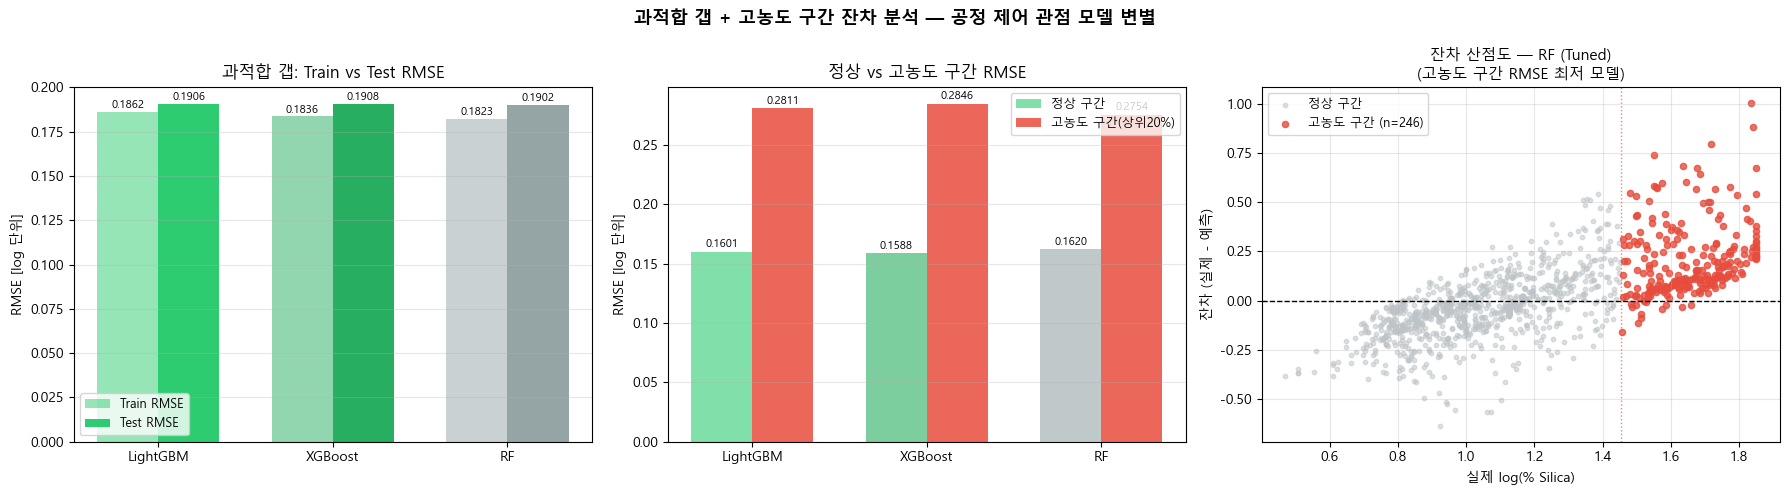

저장 완료: residual_analysis.png


In [29]:
# ══════════════════════════════════════════════════════════════════════════
# Step 16-4. 과적합 갭 + 잔차 분석
# ══════════════════════════════════════════════════════════════════════════
from sklearn.base import clone

model_names  = ['LightGBM (Tuned)', 'XGBoost (Tuned)', 'RF (Tuned)']
base_models  = [tuned_lgbm, tuned_xgb, tuned_rf]
test_preds   = [res_tuned_lgbm['pred'], res_tuned_xgb['pred'], res_tuned_rf['pred']]
colors_map   = {'LightGBM (Tuned)': '#2ecc71', 'XGBoost (Tuned)': '#27ae60', 'RF (Tuned)': '#95a5a6'}

# ── 1. Train RMSE 계산 (각 모델을 X_B_train 전체로 재학습 후 train 예측) ──
train_rmses, test_rmses, gaps = [], [], []
for base, pred_te in zip(base_models, test_preds):
    m = clone(base)
    m.fit(X_B_train, y_train)
    pred_tr   = m.predict(X_B_train)
    tr_rmse   = float(np.sqrt(mean_squared_error(y_train, pred_tr)))
    te_rmse   = float(np.sqrt(mean_squared_error(y_test,  pred_te)))
    train_rmses.append(tr_rmse)
    test_rmses.append(te_rmse)
    gaps.append(te_rmse - tr_rmse)

# ── 2. 고농도 구간 잔차 분석 (실리카 상위 20%) ────────────────────────────
y_te_arr  = y_test.values
threshold = np.percentile(y_te_arr, 80)  # 상위 20% 기준값
high_mask = y_te_arr >= threshold
norm_mask = ~high_mask

high_rmses, norm_rmses = [], []
for pred_te in test_preds:
    resid = y_te_arr - pred_te
    high_rmses.append(float(np.sqrt(np.mean(resid[high_mask]**2))))
    norm_rmses.append(float(np.sqrt(np.mean(resid[norm_mask]**2))))

# ── 텍스트 출력 ──────────────────────────────────────────────────────────
SEP = '=' * 72
print(f'\n{SEP}')
print(f'  {"모델":<22s}  {"Train RMSE":>10s}  {"Test RMSE":>10s}  {"Gap(과적합)": >12s}')
print(f'  {"-"*68}')
for name, tr, te, gap in zip(model_names, train_rmses, test_rmses, gaps):
    print(f'  {name:<22s}  {tr:>10.4f}  {te:>10.4f}  {gap:>+12.4f}')
print(SEP)
print(f'  ※ Gap = Test - Train RMSE  (작을수록 일반화 잘 됨)\n')

print(f'  {"모델":<22s}  {"전체 RMSE":>10s}  {"정상 구간":>10s}  {"고농도 구간(상위20%)": >20s}')
print(f'  {"-"*68}')
for name, te, h, n in zip(model_names, test_rmses, high_rmses, norm_rmses):
    print(f'  {name:<22s}  {te:>10.4f}  {n:>10.4f}  {h:>20.4f}')
print(SEP)
print(f'  ※ 고농도 구간: y_test 상위 20% (threshold = {threshold:.4f})')
print(f'  ※ 고농도 = 실리카 농도 높음 = 공정 이상 → 제어 중요 구간')

# ── 시각화 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x      = np.arange(len(model_names))
w      = 0.35
colors = [colors_map[n] for n in model_names]

# (1) 과적합 갭: Train vs Test RMSE
b1 = axes[0].bar(x - w/2, train_rmses, w, label='Train RMSE', color=colors, alpha=0.5)
b2 = axes[0].bar(x + w/2, test_rmses,  w, label='Test RMSE',  color=colors, alpha=1.0)
for bar, val in zip(list(b1)+list(b2), train_rmses+test_rmses):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['LightGBM', 'XGBoost', 'RF'], fontsize=10)
axes[0].set_title('과적합 갭: Train vs Test RMSE', fontsize=12)
axes[0].set_ylabel('RMSE [log 단위]')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# (2) 정상 vs 고농도 구간 RMSE
b3 = axes[1].bar(x - w/2, norm_rmses, w, label='정상 구간',       color=colors, alpha=0.6)
b4 = axes[1].bar(x + w/2, high_rmses, w, label='고농도 구간(상위20%)', color='#e74c3c', alpha=0.85)
for bar, val in zip(list(b3)+list(b4), norm_rmses+high_rmses):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['LightGBM', 'XGBoost', 'RF'], fontsize=10)
axes[1].set_title('정상 vs 고농도 구간 RMSE', fontsize=12)
axes[1].set_ylabel('RMSE [log 단위]')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# (3) 잔차 산점도 (실제값 vs 잔차) — 고농도 구간 강조
best_idx  = int(np.argmin(high_rmses))
best_name = model_names[best_idx]
best_pred = test_preds[best_idx]
resid     = y_te_arr - best_pred

axes[2].scatter(y_te_arr[norm_mask], resid[norm_mask],
                color='#bdc3c7', s=10, alpha=0.5, label='정상 구간')
axes[2].scatter(y_te_arr[high_mask], resid[high_mask],
                color='#e74c3c', s=20, alpha=0.8, label=f'고농도 구간 (n={high_mask.sum()})')
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].axvline(threshold, color='#e74c3c', linewidth=1, linestyle=':', alpha=0.7)
axes[2].set_title(f'잔차 산점도 — {best_name}\n(고농도 구간 RMSE 최저 모델)', fontsize=11)
axes[2].set_xlabel('실제 log(% Silica)')
axes[2].set_ylabel('잔차 (실제 - 예측)')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle(
    '과적합 갭 + 고농도 구간 잔차 분석 — 공정 제어 관점 모델 변별',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: residual_analysis.png')
